# Avance 2. Ingeniería de características

## Equipo 41

**Proyecto:** Detección de ocultamiento de mercancía en video para retail

### Objetivo

Este notebook documenta el proceso de ingeniería de características realizado sobre los datos utilizados en el proyecto integrador. El trabajo incluye la construcción de un conjunto consolidado de clips de video, la generación de variables derivadas para describir sus propiedades, el análisis de diferencias entre fuentes, la identificación de posibles características sesgadas y la preparación de la variable objetivo para un problema de clasificación binaria.

Debido a que los datos principales del proyecto son videos, las operaciones de ingeniería de características se adaptan a una unidad de análisis temporal. En esta etapa se trabaja con clips provenientes de diferentes fuentes y se conservan características relacionadas con su origen, duración, etiqueta y elegibilidad para los experimentos posteriores.

### Relación entre la rúbrica y el tratamiento de datos de video

La adaptación de la ingeniería de características al dominio de video fue prevista desde la planeación del proyecto. En los avances anteriores se estableció que esta etapa incluiría la preparación de representaciones adecuadas para reconocimiento de acciones, mediante operaciones como segmentación temporal, muestreo de frames, ajuste de resolución y normalización. El análisis exploratorio del Avance 1 permitió posteriormente precisar estas decisiones a partir de las características observadas en las fuentes disponibles.

| Criterio de la rúbrica | Aplicación en este notebook |
|---|---|
| Construcción de nuevas características | Consolidación de clips, generación de variables derivadas de duración y elegibilidad, conservación de variables de control y codificación de la clase objetivo. |
| Normalización y transformación | Muestreo temporal uniforme, normalización de la dimensión espacial y transformación y normalización de valores RGB. |
| Selección y extracción de características | Selección de clips elegibles, reducción de la representación temporal y espacial, exclusión de variables con riesgo de sesgo y extracción posterior de representaciones espacio-temporales mediante modelos de reconocimiento de acciones. |
| Conclusiones de Data Preparation | Documentación de las decisiones tomadas, riesgos identificados, controles necesarios y condiciones que deberán mantenerse durante el modelado y la evaluación. |

En este contexto, el muestreo temporal y la reducción espacial modifican la representación de entrada del video, mientras que las características espacio-temporales utilizadas para la clasificación serán aprendidas posteriormente por las arquitecturas de reconocimiento de acciones.

**Alcance de este notebook.** Este notebook desarrolla la preparación de la representación RGB utilizada para los experimentos de reconocimiento de acciones. RetailS utiliza una representación diferente basada en personas, cuadros y puntos corporales, por lo que su preparación se mantiene como un pipeline independiente de secuencias de pose y no se integra directamente con las transformaciones RGB documentadas aquí.

## 1. Construcción de nuevas características

### 1.1 Fuentes incluidas en el dataset consolidado

Para los experimentos basados en información RGB se consolidaron clips provenientes de cuatro fuentes. Debido a que durante la preparación se utilizaron nombres operativos distintos de los empleados en los avances anteriores, se conserva la siguiente correspondencia para mantener la trazabilidad:

| Nombre en el dataset consolidado | Fuente documentada en avances anteriores | Uso en este notebook |
|---|---|---|
| `CCTV_YOLO` | CCTV Shoplifting / Simuletic | Videos RGB de escenas de retail generadas por computadora, preparados como clips para los experimentos RGB. |
| `DCSASS` | UCF-Crime / Anomaly Detection Dataset UCF, categoría Shoplifting | Clips asociados con la categoría Shoplifting que fueron revisados para determinar su correspondencia con las clases del proyecto. |
| `MNNIT` | MNNIT Shoplifting Dataset | Videos actuados de las clases originales Normal y Shoplifting, revisados y segmentados para las clases del proyecto. |
| `SINTETICO` | Videos sintéticos adicionales proporcionados por BNext | Videos sintéticos revisados y segmentados para complementar las condiciones representadas en las demás fuentes RGB. |

Cada fuente presenta diferencias en duración, distribución de clases y forma de organización de los videos. Por esta razón, antes de aplicar normalización o preparar los datos para entrenamiento, se conservó la trazabilidad de cada clip mediante su dataset de origen, identificador de video, identificador de clip y etiqueta.

El dataset **RetailS** no se incluye en esta consolidación porque utiliza una representación basada en pose corporal. Su preparación se mantiene como un pipeline independiente de secuencias de pose, separado de las transformaciones RGB documentadas en este notebook.

Los registros cuya etiqueta no corresponde de forma clara con alguna de las dos clases objetivo no se forzaron a `ocultamiento` o `sin_ocultamiento`. En DCSASS, el caso etiquetado como `no_determinado` se conservó en la información de trazabilidad de la fuente, pero no se incorporó al conjunto físico consolidado utilizado en los experimentos. En SINTETICO, los casos etiquetados como `ambiguo` se conservaron dentro del dataset consolidado para análisis y trazabilidad, pero posteriormente se excluyen del subconjunto elegible para clasificación binaria.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Directorio de trabajo para la preparación de datos
BASE_DIR = Path(
    "/opt/workspace/MNA---Proyecto-Integrador/"
    "Datos/Preparacion_Datasets"
)

# Archivos generados durante la preparación
MANIFEST_PATH = BASE_DIR / "dataset_manifest_todos.csv"

FEATURES_PATH = (
    BASE_DIR / "dataset_consolidado_features.csv"
)

DURACIONES_PATH = (
    BASE_DIR / "duraciones_dataset_consolidado.csv"
)

# Dataset físico consolidado
CLIPS_DIR = Path(
    "/opt/workspace/datasets/procesados/clips_4s"
)

print("Manifest disponible:    ", MANIFEST_PATH.exists())
print("Features disponibles:    ", FEATURES_PATH.exists())
print("Duraciones disponibles:  ", DURACIONES_PATH.exists())
print("Directorio de clips:     ", CLIPS_DIR.exists())

Manifest disponible:     True
Features disponibles:     True
Duraciones disponibles:   True
Directorio de clips:      True


In [2]:
df = pd.read_csv(FEATURES_PATH)

print(f"Registros del dataset consolidado: {len(df)}")
print(f"Columnas disponibles: {len(df.columns)}")

df.head()

Registros del dataset consolidado: 987
Columnas disponibles: 19


,dataset,video_id,video_origen,clip_id,inicio_s,fin_s,etiqueta,persona_id,evento_id,nota,nombre_clip,duracion_real_s,duracion_objetivo_s,diferencia_vs_4s,cumple_4s,requiere_normalizacion_temporal,elegible_modelo_binario,motivo_no_elegible,clase_binaria
0,CCTV_YOLO,CCTV_001,not_shoplifting1.mp4,CCTV_001,2.0,6.0,sin_ocultamiento,P001_AJ,NaN,NaN,CCTV_YOLO__CCTV_001__CCTV_001.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
1,CCTV_YOLO,CCTV_002,not_shoplifting2.mp4,CCTV_002,2.0,6.0,sin_ocultamiento,P002_AJ,NaN,NaN,CCTV_YOLO__CCTV_002__CCTV_002.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
2,CCTV_YOLO,CCTV_003,not_shoplifting3.mp4,CCTV_003,2.0,6.0,sin_ocultamiento,P003_AJ,NaN,NaN,CCTV_YOLO__CCTV_003__CCTV_003.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
3,CCTV_YOLO,CCTV_004,not_shoplifting4.mp4,CCTV_004,2.0,6.0,sin_ocultamiento,P004_AJ,NaN,NaN,CCTV_YOLO__CCTV_004__CCTV_004.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
4,CCTV_YOLO,CCTV_005,shoplifting1.mp4,CCTV_005,2.0,6.0,ocultamiento,P001_AJ,NaN,NaN,CCTV_YOLO__CCTV_005__CCTV_005.mp4,4.0,4.0,0.0,True,False,True,NaN,1.0


In [3]:
conteo_por_dataset = (
    df["dataset"]
    .value_counts()
    .rename_axis("dataset")
    .reset_index(name="clips")
)

conteo_por_dataset["porcentaje"] = (
    conteo_por_dataset["clips"]
    / len(df)
    * 100
).round(2)

conteo_por_dataset

,dataset,clips,porcentaje
0,DCSASS,783,79.33
1,MNNIT,182,18.44
2,SINTETICO,14,1.42
3,CCTV_YOLO,8,0.81


#### 1.1.1 Dataset descartado: venta_sospechosa

Durante la revisión de las fuentes disponibles se analizó también el dataset `venta_sospechosa`. Los videos se encuentran organizados en particiones de entrenamiento y evaluación, y representan actividades sospechosas realizadas principalmente por cajeros en tiendas de conveniencia pequeñas.

Entre las acciones observadas se encuentran abrir la caja de cobro sin que exista una venta, retirar dinero de la caja y cobrar sin depositar posteriormente el efectivo. Estas acciones corresponden a comportamientos anómalos en el punto de venta, pero presentan una relación semántica limitada con la acción objetivo de este proyecto: el ocultamiento de mercancía.

Su incorporación podría introducir señales visuales asociadas con la caja registradora, el manejo de efectivo, la posición del cajero o la interacción con el punto de venta. Un modelo podría aprender estas características como atajos para identificar comportamiento sospechoso, aunque no exista un producto ni una acción de ocultamiento.

Por este motivo, `venta_sospechosa` se excluyó del dataset consolidado utilizado en los experimentos de reconocimiento de ocultamiento. La decisión se basó en la correspondencia entre el contenido de los videos y la definición operacional de la clase objetivo, con el propósito de reducir el riesgo de aprendizaje de características ajenas a la acción que se desea detectar.

#### 1.1.2 Justificación de la mezcla de fuentes

BNext no proporcionó videos reales de ocultamiento obtenidos en las tiendas donde eventualmente podría utilizarse el sistema. Por esta razón, el dataset consolidado se construyó utilizando diferentes fuentes públicas y videos sintéticos que contienen ejemplos relacionados con la acción objetivo.

La combinación de fuentes también introduce diversidad en las condiciones visuales de los datos. En una implementación real en múltiples tiendas podrían existir diferencias en cámaras, DVR, resolución, frecuencia de cuadros, compresión, iluminación, posición y ángulo de las cámaras, distribución física de la tienda y niveles de oclusión. La presencia de condiciones distintas entre los datasets disponibles permite aproximar parcialmente esta heterogeneidad durante la etapa experimental.

Esta estrategia se considera una forma provisional de aumentar la diversidad del dominio de entrenamiento y evaluar si las características relacionadas con la acción pueden mantenerse bajo diferentes condiciones de captura. Sin embargo, la mezcla de datasets públicos y sintéticos no sustituye la validación con videos reales del dominio operativo de BNext.

Además, la heterogeneidad entre fuentes puede introducir sesgos. Durante el análisis se identificaron diferencias de duración, resolución, frecuencia de cuadros y distribución de clases asociadas con el dataset de origen. Por esta razón, estas características se controlan durante la preparación de los datos y deberán considerarse en la estrategia de partición y evaluación para reducir el riesgo de que el modelo aprenda señales propias de una fuente en lugar de la acción de ocultamiento.

#### 1.1.3 Uso de clips presegmentados de DCSASS

La fuente asociada con UCF-Crime fue caracterizada inicialmente a nivel de videos de vigilancia completos. Para la preparación de los experimentos RGB, el material utilizado bajo el nombre operativo `DCSASS` corresponde a clips previamente segmentados asociados con la categoría Shoplifting.

Se decidió trabajar con estos clips en lugar de volver a segmentar los videos largos porque la unidad experimental del proyecto requiere secuencias temporales acotadas en las que pueda revisarse directamente la acción observable. Una etiqueta general de Shoplifting en un video largo no garantiza que todos sus intervalos contengan un evento de ocultamiento, por lo que utilizar la etiqueta global sobre fragmentos generados automáticamente podría introducir ruido de anotación.

Los 896 clips DCSASS disponibles fueron revisados visualmente. A partir de esa revisión se seleccionaron los segmentos con contenido pertinente para las clases del proyecto y, dentro de ese subconjunto, se asignaron las etiquetas de acuerdo con la acción observable. Los archivos presentan duraciones físicas entre 1 y 5 segundos y se conservan completos, posteriormente se representan mediante 16 frames muestreados uniformemente a lo largo de su duración.

Esta decisión permite utilizar una unidad de análisis más cercana al evento y evita introducir una nueva segmentación temporal sobre archivos que ya fueron revisados. Sin embargo, el uso de una colección presegmentada también puede introducir sesgo de selección, ya que los clips disponibles no representan necesariamente toda la variabilidad temporal y contextual de los videos largos de origen. Por esta razón, la procedencia y el proceso de selección de DCSASS deben conservarse como parte de la trazabilidad del dataset.

#### 1.1.4 Trazabilidad de la selección DCSASS

La estructura física disponible de DCSASS contiene 28 grupos de origen con 32 clips cada uno, para un total de 896 archivos MP4. Los 896 clips fueron revisados visualmente para determinar si su contenido aportaba evidencia útil para alguna de las dos clases definidas en el proyecto.

Como resultado de esta revisión, 112 clips fueron descartados por no contener información pertinente para distinguir entre `ocultamiento` y `sin_ocultamiento`. Entre estos casos se observaron, por ejemplo, tomas de estantes sin personas y otros segmentos sin una interacción observable que permitiera evaluar la acción objetivo. Estos archivos no se consideraron ejemplos de `sin_ocultamiento`, ya que esa clase busca representar comportamientos observables de personas que no culminan en ocultamiento.

Los 784 clips restantes fueron registrados en `dataset_manifest_todos.csv`. La reducción no fue uniforme entre los 28 grupos de origen: veinte conservaron sus 32 clips, siete quedaron parcialmente representados y uno, `Shoplifting007_x264`, no aportó clips al manifiesto después de aplicar el criterio de pertinencia visual.

| Video de origen | Clips físicos | Clips en manifiesto | Clips descartados |
|---|---:|---:|---:|
| `Shoplifting001_x264` | 32 | 22 | 10 |
| `Shoplifting005_x264` | 32 | 15 | 17 |
| `Shoplifting006_x264` | 32 | 16 | 16 |
| `Shoplifting007_x264` | 32 | 0 | 32 |
| `Shoplifting009_x264` | 32 | 17 | 15 |
| `Shoplifting013_x264` | 32 | 26 | 6 |
| `Shoplifting018_x264` | 32 | 17 | 15 |
| `Shoplifting047_x264` | 32 | 31 | 1 |

Dentro de los 784 registros seleccionados, 783 pudieron asociarse con una de las dos clases del problema binario y uno se mantuvo como `no_determinado`. Este último se conserva para trazabilidad, pero no se incorpora al subconjunto DCSASS elegible para los experimentos supervisados.

El criterio de selección utilizado en esta etapa restringe el conjunto a clips con contenido visual pertinente para estudiar la acción. Esta decisión es coherente con un experimento de clasificación de acciones sobre clips candidatos, pero también delimita su alcance: el dataset preparado no representa por sí solo el problema adicional de localizar eventos de interés dentro de video continuo que puede contener largos periodos sin personas o sin interacción con mercancía.

In [4]:
# Auditoría reproducible de la selección DCSASS

DCSASS_SOURCE = Path(
    "/opt/workspace/datasets/"
    "Anomaly Detection Dataset UCF/"
    "Shoplifting_Clips"
)

# ---------------------------------------------------------
# 1. Inventario físico
# ---------------------------------------------------------
archivos_dcsass = sorted(
    p for p in DCSASS_SOURCE.rglob("*.mp4")
    if p.is_file()
)

fisicos_dcsass = pd.DataFrame([
    {
        "video_id": p.parent.name.removesuffix(".mp4"),
        "video_origen": p.name
    }
    for p in archivos_dcsass
])

# ---------------------------------------------------------
# 2. Registros del manifiesto
# ---------------------------------------------------------
manifest_audit = pd.read_csv(MANIFEST_PATH)

manifest_dcsass = (
    manifest_audit[
        manifest_audit["dataset"].eq("DCSASS")
    ]
    .copy()
)

# ---------------------------------------------------------
# 3. Validación de claves y correspondencia física
# ---------------------------------------------------------
clave = ["video_id", "video_origen"]

duplicados_fisicos = fisicos_dcsass.duplicated(
    subset=clave
).sum()

duplicados_manifest = manifest_dcsass.duplicated(
    subset=clave
).sum()

comparacion_dcsass = fisicos_dcsass.merge(
    manifest_dcsass[
        ["video_id", "video_origen", "etiqueta"]
    ],
    on=clave,
    how="left",
    indicator=True
)

clips_fuera_manifest = (
    comparacion_dcsass["_merge"]
    .eq("left_only")
    .sum()
)

clips_en_manifest = (
    comparacion_dcsass["_merge"]
    .eq("both")
    .sum()
)

# ---------------------------------------------------------
# 4. Cobertura por video de origen
# ---------------------------------------------------------
cobertura_video = (
    comparacion_dcsass
    .assign(
        incluido=lambda x: x["_merge"].eq("both")
    )
    .groupby("video_id")
    .agg(
        clips_fisicos=("video_origen", "size"),
        clips_manifest=("incluido", "sum")
    )
    .reset_index()
)

cobertura_video["clips_descartados"] = (
    cobertura_video["clips_fisicos"]
    - cobertura_video["clips_manifest"]
)

videos_completos = (
    cobertura_video["clips_manifest"]
    .eq(cobertura_video["clips_fisicos"])
    .sum()
)

videos_excluidos = (
    cobertura_video["clips_manifest"]
    .eq(0)
    .sum()
)

videos_parciales = (
    (
        cobertura_video["clips_manifest"].gt(0)
        & cobertura_video["clips_manifest"].lt(
            cobertura_video["clips_fisicos"]
        )
    )
    .sum()
)

# ---------------------------------------------------------
# 5. Elegibilidad binaria
# ---------------------------------------------------------
etiquetas_binarias = [
    "ocultamiento",
    "sin_ocultamiento"
]

elegibles_binarios = (
    manifest_dcsass["etiqueta"]
    .isin(etiquetas_binarias)
    .sum()
)

no_binarios = (
    ~manifest_dcsass["etiqueta"]
    .isin(etiquetas_binarias)
).sum()

# ---------------------------------------------------------
# 6. Comprobaciones de integridad
# ---------------------------------------------------------
assert duplicados_fisicos == 0
assert duplicados_manifest == 0
assert clips_en_manifest == len(manifest_dcsass)
assert (
    clips_en_manifest + clips_fuera_manifest
    == len(fisicos_dcsass)
)
assert (
    videos_completos
    + videos_parciales
    + videos_excluidos
    == cobertura_video["video_id"].nunique()
)
assert (
    elegibles_binarios + no_binarios
    == len(manifest_dcsass)
)

# ---------------------------------------------------------
# 7. Resumen del embudo
# ---------------------------------------------------------
resumen_embudo = pd.DataFrame({
    "Indicador": [
        "Clips físicos DCSASS",
        "Clips seleccionados en manifiesto",
        "Clips descartados tras revisión visual",
        "Videos de origen completos",
        "Videos de origen parcialmente incluidos",
        "Videos de origen totalmente excluidos",
        "Clips elegibles para clasificación binaria",
        "Clips no binarios"
    ],
    "Cantidad": [
        len(fisicos_dcsass),
        clips_en_manifest,
        clips_fuera_manifest,
        videos_completos,
        videos_parciales,
        videos_excluidos,
        elegibles_binarios,
        no_binarios
    ]
})

display(resumen_embudo)

print("\nVideos de origen afectados por la selección:")

display(
    cobertura_video[
        cobertura_video["clips_descartados"].gt(0)
    ].reset_index(drop=True)
)

,Indicador,Cantidad
0,Clips físicos DCSASS,896
1,Clips seleccionados en manifiesto,784
2,Clips descartados tras revisión visual,112
3,Videos de origen completos,20
4,Videos de origen parcialmente incluidos,7
5,Videos de origen totalmente excluidos,1
6,Clips elegibles para clasificación binaria,783
7,Clips no binarios,1



Videos de origen afectados por la selección:


,video_id,clips_fisicos,clips_manifest,clips_descartados
0,Shoplifting001_x264,32,22,10
1,Shoplifting005_x264,32,15,17
2,Shoplifting006_x264,32,16,16
3,Shoplifting007_x264,32,0,32
4,Shoplifting009_x264,32,17,15
5,Shoplifting013_x264,32,26,6
6,Shoplifting018_x264,32,17,15
7,Shoplifting047_x264,32,31,1


#### 1.1.5 Relación de DCSASS con un escenario operativo de vigilancia

La revisión de DCSASS también permite identificar una característica relevante para el escenario operativo del proyecto. Aunque los archivos disponibles en esta fuente ya se encuentran segmentados en clips cortos y, por tanto, no reproducen directamente horas continuas de videovigilancia, su proceso de revisión muestra que no todo fragmento proveniente de un video asociado con shoplifting aporta información útil para distinguir las clases del proyecto.

De los 896 clips físicos revisados, 112 no contenían contenido visual pertinente para `ocultamiento` o `sin_ocultamiento`, por ejemplo segmentos con estantes sin personas o sin una interacción observable con mercancía. Incluso uno de los 28 grupos de origen no aportó ningún clip después de aplicar el criterio de pertinencia.

Este comportamiento aproxima parcialmente una condición esperable en un sistema de vigilancia real: una parte importante del flujo de video puede no constituir una muestra útil para un clasificador de acciones. Antes de decidir si existe ocultamiento, un sistema operativo requeriría identificar intervalos candidatos en los que exista actividad relevante, por ejemplo presencia de personas e interacción con productos.

En este proyecto, esa etapa de localización o generación automática de candidatos no forma parte todavía del experimento RGB baseline. Los modelos evaluados recibirán clips previamente seleccionados como unidades de análisis. Por ello, los resultados obtenidos medirán principalmente la capacidad de distinguir `ocultamiento` de `sin_ocultamiento` sobre clips pertinentes, y no la capacidad de encontrar automáticamente esos eventos dentro de un flujo continuo de videovigilancia.

Esta distinción es relevante para interpretar los resultados en el contexto de BNext. La demostración sobre clips candidatos representa una primera validación del reconocimiento de la acción. Una solución operativa requeriría además una etapa previa capaz de reducir el flujo continuo de video a segmentos susceptibles de análisis.

#### 1.1.6 Trazabilidad documental y restricciones de las fuentes

Además de conservar la procedencia técnica de cada clip mediante las variables del manifiesto, se registró el estado documental conocido de las fuentes utilizadas. Esta distinción es relevante porque la disponibilidad de un dataset para experimentación no implica necesariamente autorización para redistribuir sus archivos originales o derivados.

| Fuente utilizada en el proyecto | Procedencia documentada | Uso en este avance | Estado documental para uso o redistribución |
|---|---|---|---|
| `CCTV_YOLO` | Muestras del dataset CCTV Shoplifting / Simuletic utilizadas previamente en el proyecto | Generación de clips RGB etiquetados | La fuente fue documentada previamente con licencia CC BY 4.0. Debe conservarse la atribución correspondiente si se reutiliza o redistribuye material derivado. |
| `DCSASS` | Colección local `Anomaly Detection Dataset UCF/Shoplifting_Clips`, asociada con material de Shoplifting derivado del dominio UCF-Crime | Principal fuente de clips RGB revisados visualmente | La procedencia técnica se conserva en el manifiesto, pero el permiso explícito de redistribución de esta versión de los clips no se considera verificado en este avance. Por ello, los archivos de video no deben publicarse automáticamente junto con el código. |
| `MNNIT` | MNNIT Shoplifting Dataset | Generación de clips RGB de `ocultamiento` y `sin_ocultamiento` | La fuente original fue documentada previamente con licencia CC BY 4.0. Deben conservarse la referencia y atribución de la fuente. |
| `SINTETICO` | Videos sintéticos proporcionados por BNext para el proyecto | Fuente suplementaria de ejemplos RGB | No corresponde a un dataset público. Su uso se limita al contexto autorizado del proyecto y cualquier redistribución deberá respetar las condiciones acordadas con BNext. |
| `RetailS` | Dataset con información de pose corporal | Pipeline independiente basado en secuencias de puntos corporales | No forma parte del dataset RGB consolidado. El estado de redistribución deberá verificarse antes de publicar datos derivados o archivos de la fuente. |

Por esta razón, el repositorio del proyecto debe separar el código, los manifiestos y la documentación de los archivos físicos de video. Los scripts de preparación pueden mantenerse en el repositorio para asegurar reproducibilidad, mientras que los datasets originales y los clips sujetos a restricciones deben conservarse en almacenamiento autorizado.

La trazabilidad se mantiene mediante los campos `dataset`, `video_id`, `video_origen` y `clip_id`, de manera que cada observación utilizada en los experimentos pueda relacionarse con su fuente y con las transformaciones aplicadas durante la preparación.

### 1.2 Composición del dataset consolidado

El dataset consolidado contiene **987 clips** provenientes de cuatro fuentes. DCSASS aporta la mayor cantidad de observaciones, con 783 clips, equivalentes al 79.33% del total. MNNIT representa el 18.44%, mientras que CCTV_YOLO y SINTETICO tienen una participación considerablemente menor.

Esta distribución muestra que las fuentes no contribuyen de manera uniforme al conjunto consolidado. Por esta razón, la variable `dataset` se conserva como una característica de control y trazabilidad. No se utilizará directamente como entrada del modelo, pero permitirá analizar posteriormente si el desempeño está condicionado por características propias de alguna fuente.

In [5]:
archivos_fisicos = {
    p.name
    for p in CLIPS_DIR.glob("*.mp4")
    if p.is_file()
}

clips_manifestados = set(
    df["nombre_clip"]
    .dropna()
    .astype(str)
    .str.strip()
)

faltantes = sorted(
    clips_manifestados - archivos_fisicos
)

extras = sorted(
    archivos_fisicos - clips_manifestados
)

print(f"Clips esperados en el consolidado: {len(clips_manifestados)}")
print(f"Archivos MP4 encontrados:          {len(archivos_fisicos)}")
print(f"Archivos faltantes:                {len(faltantes)}")
print(f"Archivos extras:                   {len(extras)}")

Clips esperados en el consolidado: 987
Archivos MP4 encontrados:          987
Archivos faltantes:                0
Archivos extras:                   0


In [6]:
# Relación entre videos de origen y clips derivados

# Una identidad de video debe incluir también la fuente.
df_origen = df.copy()

resumen_origen = (
    df_origen
    .groupby("dataset")
    .agg(
        clips=("clip_id", "size"),
        videos_origen=("video_id", "nunique")
    )
    .reset_index()
)

resumen_origen["clips_por_video_promedio"] = (
    resumen_origen["clips"]
    / resumen_origen["videos_origen"]
).round(2)

# Número de clips derivados de cada video de origen
clips_por_video = (
    df_origen
    .groupby(["dataset", "video_id"])
    .size()
    .rename("clips_derivados")
    .reset_index()
)

resumen_dependencia = (
    clips_por_video
    .groupby("dataset")["clips_derivados"]
    .agg(
        videos_origen="count",
        min_clips="min",
        mediana_clips="median",
        media_clips="mean",
        max_clips="max"
    )
    .reset_index()
)

resumen_dependencia["media_clips"] = (
    resumen_dependencia["media_clips"]
    .round(2)
)

print("Resumen de clips y videos de origen:")
display(resumen_origen)

print("\nDistribución de clips derivados por video de origen:")
display(resumen_dependencia)

videos_multiclip = (
    clips_por_video["clips_derivados"] > 1
).sum()

print(
    "\nVideos de origen que aportan más de un clip:",
    videos_multiclip
)

print(
    "Fuentes con videos que aportan más de un clip:",
    clips_por_video.loc[
        clips_por_video["clips_derivados"] > 1,
        "dataset"
    ].unique().tolist()
)

Resumen de clips y videos de origen:


,dataset,clips,videos_origen,clips_por_video_promedio
0,CCTV_YOLO,8,8,1.0
1,DCSASS,783,27,29.0
2,MNNIT,182,182,1.0
3,SINTETICO,14,14,1.0



Distribución de clips derivados por video de origen:


,dataset,videos_origen,min_clips,mediana_clips,media_clips,max_clips
0,CCTV_YOLO,8,1,1.0,1.0,1
1,DCSASS,27,15,32.0,29.0,32
2,MNNIT,182,1,1.0,1.0,1
3,SINTETICO,14,1,1.0,1.0,1



Videos de origen que aportan más de un clip: 27
Fuentes con videos que aportan más de un clip: ['DCSASS']


#### 1.2.1 Dependencia entre clips y videos de origen

El número de clips no equivale al número de videos de origen representados en el dataset. Esta diferencia es especialmente relevante en DCSASS: los 783 clips incorporados al dataset consolidado proceden de 27 identificadores de video, con una media de 29 clips por video y una mediana de 32. En cambio, CCTV_YOLO, MNNIT y SINTETICO aportan actualmente un clip por cada `video_id` registrado.

Esta estructura implica que los clips DCSASS derivados de un mismo video comparten condiciones visuales y contextuales. Por ello, una partición aleatoria realizada directamente a nivel de clip podría colocar muestras relacionadas en entrenamiento, validación y prueba, produciendo fuga de información y una estimación optimista del desempeño.

Para los experimentos posteriores, todos los clips asociados con la misma combinación de `dataset` y `video_id` deberán permanecer en una única partición. Esta agrupación constituye el nivel mínimo de control de procedencia. Cuando existan identificadores confiables de persona, evento o escenario, también deberán considerarse para evitar separar entre particiones ejemplos que continúen estando estrechamente relacionados aunque tengan distinto `video_id`.

La diferencia entre los 22 registros de `Shoplifting001_x264` observados en el manifiesto y los 21 presentes en el dataset consolidado se debe a que uno de sus clips permanece como `no_determinado`. Este registro conserva su trazabilidad en el manifiesto, pero no forma parte de los 783 clips DCSASS incorporados al subconjunto binario.

### 1.3 Validación del dataset consolidado

La validación entre el manifiesto enriquecido y los archivos físicos confirmó una correspondencia completa entre ambos. El dataset contiene **987 clips esperados y 987 archivos MP4 disponibles**, sin archivos faltantes ni archivos adicionales.

Esta verificación permite utilizar `dataset_consolidado_features.csv` como referencia para los análisis posteriores, manteniendo la trazabilidad entre cada registro tabular y su clip de video correspondiente.

### 1.4 Scripts utilizados para la preparación y validación

Las operaciones de preparación se implementaron mediante scripts independientes para mantener separado el procesamiento operativo del análisis presentado en este notebook. Los scripts se encuentran en `Datos/Preparacion_Datasets/scripts/`.

| Script | Propósito |
|---|---|
| `generar_clips_4s.py` | Generar clips a partir de CCTV_YOLO, MNNIT y SINTETICO utilizando los intervalos definidos en el manifiesto. |
| `validar_clips_4s.py` | Verificar cantidad, duración y existencia de stream de video en los clips generados. |
| `extraer_dcsass.py` | Extraer y validar la estructura de los clips DCSASS disponibles en el archivo comprimido. |
| `validar_dcsass_manifest.py` | Comprobar la correspondencia entre los archivos físicos DCSASS y los registros del manifiesto. |
| `auditar_dcsass_seleccion.py` | Analizar las etiquetas de DCSASS y determinar los clips elegibles para el problema binario. |
| `incorporar_dcsass.py` | Incorporar al dataset consolidado los clips DCSASS seleccionados por el manifiesto. |
| `validar_dataset_unificado.py` | Verificar correspondencia entre el dataset consolidado, el manifiesto y los archivos físicos, además de revisar decodificación y duración. |
| `analizar_duraciones_consolidado.py` | Medir la duración real de los clips y generar las características temporales utilizadas en el análisis. |
| `analizar_sesgo_fuente_duracion.py` | Analizar la relación entre fuente, duración y etiqueta para identificar posibles características sesgadas. |
| `crear_dataset_consolidado_features.py` | Construir `dataset_consolidado_features.csv` integrando trazabilidad y características derivadas. |
| `codificar_clase_binaria.py` | Generar la representación numérica de la variable objetivo para el problema binario. |

Esta organización permite reproducir el proceso de preparación sin duplicar en el notebook el código operacional completo. El notebook utiliza los artefactos resultantes para mostrar las validaciones, análisis y decisiones de ingeniería de características.

Los scripts y manifiestos se conservan como parte reproducible del proceso de preparación. Los archivos físicos de video se mantienen fuera del repositorio de código cuando su licencia o las condiciones de uso no permiten asumir su redistribución.

In [7]:
columnas_features = [
    "dataset",
    "clip_id",
    "etiqueta",
    "duracion_real_s",
    "duracion_objetivo_s",
    "diferencia_vs_4s",
    "cumple_4s",
    "requiere_normalizacion_temporal",
    "elegible_modelo_binario",
    "motivo_no_elegible",
    "clase_binaria",
]

df[columnas_features].head(10)

,dataset,clip_id,etiqueta,duracion_real_s,duracion_objetivo_s,diferencia_vs_4s,cumple_4s,requiere_normalizacion_temporal,elegible_modelo_binario,motivo_no_elegible,clase_binaria
0,CCTV_YOLO,CCTV_001,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
1,CCTV_YOLO,CCTV_002,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
2,CCTV_YOLO,CCTV_003,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
3,CCTV_YOLO,CCTV_004,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
4,CCTV_YOLO,CCTV_005,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
5,CCTV_YOLO,CCTV_006,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
6,CCTV_YOLO,CCTV_007,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
7,CCTV_YOLO,CCTV_008,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
8,MNNIT,MNNIT_001,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
9,MNNIT,MNNIT_002,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0


### 1.5 Características derivadas

A partir de la información original del manifiesto y de mediciones realizadas sobre los archivos de video se generaron características adicionales para apoyar la preparación y evaluación posterior de los datos:

- **`duracion_real_s`**: duración real del clip medida directamente sobre el archivo de video mediante `ffprobe`.
- **`duracion_objetivo_s`**: referencia temporal de 4 segundos considerada inicialmente para uniformar la unidad de análisis.
- **`diferencia_vs_4s`**: diferencia entre la duración real del clip y la duración de referencia.
- **`cumple_4s`**: indica si la duración del clip se encuentra dentro de la tolerancia definida alrededor de 4 segundos.
- **`requiere_normalizacion_temporal`**: identifica los clips cuya duración física difiere de la referencia inicial de 4 segundos y que, por ello, evidenciaron la necesidad de definir una estrategia de representación temporal uniforme. Esta variable se conserva para análisis y trazabilidad; el baseline aplicará posteriormente el muestreo uniforme de 16 frames a todos los clips.
- **`elegible_modelo_binario`**: indica si la etiqueta del clip pertenece a las dos clases utilizadas en el problema de clasificación: `ocultamiento` y `sin_ocultamiento`.
- **`motivo_no_elegible`**: conserva la razón por la que un clip no se utiliza en el problema binario.
- **`clase_binaria`**: representación numérica de la variable objetivo, donde `sin_ocultamiento = 0` y `ocultamiento = 1`. Las etiquetas ambiguas se mantienen sin asignación numérica.

Estas variables se utilizan para control, análisis y preparación de los experimentos. Las características relacionadas con la fuente o la duración no se consideran directamente como entradas del modelo RGB, ya que podrían introducir información asociada al origen de los datos en lugar de representar la acción de ocultamiento.

### 1.6 Distribución de la duración real de los clips

In [8]:
resumen_duracion = pd.Series({
    "clips": len(df),
    "duracion_min_s": df["duracion_real_s"].min(),
    "duracion_max_s": df["duracion_real_s"].max(),
    "duracion_media_s": df["duracion_real_s"].mean(),
    "duracion_mediana_s": df["duracion_real_s"].median(),
    "clips_aprox_4s": df["cumple_4s"].sum(),
    "clips_fuera_4s": (~df["cumple_4s"]).sum(),
})

display(resumen_duracion.to_frame("valor"))

distribucion_duracion = (
    df["duracion_real_s"]
    .value_counts()
    .sort_index()
    .rename_axis("duracion_s")
    .reset_index(name="clips")
)

distribucion_duracion

,valor
clips,987.000000
duracion_min_s,1.000000
duracion_max_s,5.000000
duracion_media_s,2.491388
duracion_mediana_s,2.000000
clips_aprox_4s,225.000000
clips_fuera_4s,762.000000


,duracion_s,clips
0,1.0,256
1,2.0,313
2,3.0,144
3,4.0,225
4,5.0,49


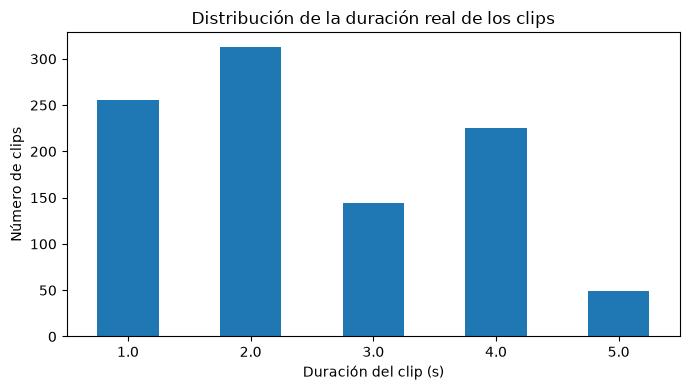

In [9]:
ax = distribucion_duracion.plot(
    x="duracion_s",
    y="clips",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)

ax.set_title("Distribución de la duración real de los clips")
ax.set_xlabel("Duración del clip (s)")
ax.set_ylabel("Número de clips")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
resumen_por_fuente = (
    df.groupby("dataset")
    .agg(
        clips=("nombre_clip", "count"),
        duracion_min_s=("duracion_real_s", "min"),
        duracion_max_s=("duracion_real_s", "max"),
        duracion_media_s=("duracion_real_s", "mean"),
        duracion_mediana_s=("duracion_real_s", "median"),
        clips_4s=("cumple_4s", "sum"),
    )
    .reset_index()
)

resumen_por_fuente["clips_fuera_4s"] = (
    resumen_por_fuente["clips"]
    - resumen_por_fuente["clips_4s"]
)

resumen_por_fuente.round(3)

,dataset,clips,duracion_min_s,duracion_max_s,duracion_media_s,duracion_mediana_s,clips_4s,clips_fuera_4s
0,CCTV_YOLO,8,4.0,4.0,4.000,4.0,8,0
1,DCSASS,783,1.0,5.0,2.098,2.0,21,762
2,MNNIT,182,4.0,4.0,4.000,4.0,182,0
3,SINTETICO,14,4.0,4.0,4.000,4.0,14,0


### 1.7 Diferencias temporales entre fuentes

El análisis por fuente muestra que la variabilidad de duración se concentra en DCSASS. Mientras que CCTV_YOLO, MNNIT y SINTETICO presentan clips de 4 segundos, DCSASS contiene clips con duraciones entre 1 y 5 segundos, con una media de 2.098 segundos.

De los 783 clips de DCSASS, únicamente 21 cumplen aproximadamente con la referencia de 4 segundos y 762 presentan una duración diferente.

Esta diferencia temporal debe considerarse durante la preparación de los datos, ya que la duración podría actuar como una característica asociada al dataset de origen. Para reducir este riesgo, la duración se utilizará como variable de control y todos los clips del baseline se representarán posteriormente mediante 16 frames distribuidos uniformemente a lo largo de su duración física.

In [11]:
df_binario = df[
    df["elegible_modelo_binario"] == True
].copy()

tabla_fuente_clase = pd.crosstab(
    df_binario["dataset"],
    df_binario["etiqueta"]
)

tabla_fuente_clase["total"] = tabla_fuente_clase.sum(axis=1)

tabla_fuente_clase["pct_ocultamiento"] = (
    tabla_fuente_clase["ocultamiento"]
    / tabla_fuente_clase["total"]
    * 100
).round(2)

tabla_fuente_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
dataset,,,,
CCTV_YOLO,4,4,8,50.00
DCSASS,84,699,783,10.73
MNNIT,92,90,182,50.55
SINTETICO,10,2,12,83.33


### 1.8 Distribución de clases por fuente

La distribución de las clases no es uniforme entre las fuentes utilizadas. En CCTV_YOLO y MNNIT aproximadamente la mitad de los clips corresponden a `ocultamiento`, mientras que en DCSASS esta clase representa únicamente el 10.73% y en SINTETICO alcanza el 83.33%.

Estas diferencias indican que existe una asociación entre la fuente de los datos y la variable objetivo. Si un modelo aprende características visuales propias de cada dataset, como resolución, cámara, escenario, iluminación o procesamiento del video, podría utilizarlas como señales indirectas para predecir la clase.

Por esta razón, la variable `dataset` se conservará para control, análisis y definición de particiones experimentales, pero no se utilizará como característica de entrada del modelo. La evaluación posterior deberá comprobar que el desempeño se mantiene cuando se utilizan datos de fuentes distintas a las observadas durante el entrenamiento.

### 1.9 Relación entre duración y etiqueta

Además de analizar las diferencias entre fuentes, se revisó si la duración de los clips presenta alguna asociación con la variable objetivo. Esta comprobación es relevante porque una característica temporal podría convertirse en una señal indirecta para distinguir las clases.

Sin embargo, la relación entre duración y etiqueta debe interpretarse considerando el dataset de origen, ya que las fuentes presentan tanto duraciones como proporciones de clase diferentes. Por ello, primero se analiza la distribución global y posteriormente se revisa el comportamiento dentro de DCSASS, que concentra la variabilidad temporal del conjunto consolidado.

In [12]:
tabla_duracion_clase = pd.crosstab(
    df_binario["duracion_real_s"],
    df_binario["etiqueta"]
)

tabla_duracion_clase["total"] = (
    tabla_duracion_clase.sum(axis=1)
)

tabla_duracion_clase["pct_ocultamiento"] = (
    tabla_duracion_clase["ocultamiento"]
    / tabla_duracion_clase["total"]
    * 100
).round(2)

tabla_duracion_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
duracion_real_s,,,,
1.0,10,246,256,3.91
2.0,54,259,313,17.25
3.0,11,133,144,7.64
4.0,108,115,223,48.43
5.0,7,42,49,14.29


In [13]:
dcsass_binario = df_binario[
    df_binario["dataset"] == "DCSASS"
].copy()

tabla_dcsass_duracion_clase = pd.crosstab(
    dcsass_binario["duracion_real_s"],
    dcsass_binario["etiqueta"]
)

tabla_dcsass_duracion_clase["total"] = (
    tabla_dcsass_duracion_clase.sum(axis=1)
)

tabla_dcsass_duracion_clase["pct_ocultamiento"] = (
    tabla_dcsass_duracion_clase["ocultamiento"]
    / tabla_dcsass_duracion_clase["total"]
    * 100
).round(2)

tabla_dcsass_duracion_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
duracion_real_s,,,,
1.0,10,246,256,3.91
2.0,54,259,313,17.25
3.0,11,133,144,7.64
4.0,2,19,21,9.52
5.0,7,42,49,14.29


#### 1.9.1 Interpretación de la relación entre duración y etiqueta

En el análisis global se observa una asociación aparente entre la duración de los clips y la clase. Por ejemplo, los clips de 4 segundos presentan 48.43% de `ocultamiento`.

Sin embargo, al analizar únicamente DCSASS, la proporción de `ocultamiento` en clips de 4 segundos disminuye a 9.52%. Esta diferencia indica que la relación global entre duración y etiqueta está condicionada por el dataset de origen.

La fuente funciona como una variable de confusión, ya que está asociada tanto con la duración de los clips como con la distribución de las clases. Además, dentro de DCSASS no se observa una tendencia monotónica entre duración y porcentaje de `ocultamiento`.

Por esta razón, la duración no se utilizará como característica predictora directa del modelo. Se conservará como variable de control para la preparación de los datos y para definir la normalización temporal requerida antes del entrenamiento.

### 1.10 Codificación de la variable objetivo

Para preparar el problema de clasificación binaria se generó la característica `clase_binaria` a partir de la etiqueta original de cada clip.

La codificación utilizada es:

- `sin_ocultamiento` = **0**
- `ocultamiento` = **1**

Los clips con etiqueta `ambiguo` se conservan en el dataset consolidado para fines de análisis, pero no reciben una clase numérica y se marcan como no elegibles para el entrenamiento binario. Esta decisión evita introducir ruido de etiqueta asignando de forma artificial una clase a observaciones cuya acción no puede determinarse con suficiente claridad.

In [14]:
tabla_codificacion = pd.crosstab(
    df["etiqueta"],
    df["clase_binaria"],
    dropna=False
)

tabla_codificacion

clase_binaria,0.0,1.0,NaN
etiqueta,,,
ambiguo,0,0,2
ocultamiento,0,190,0
sin_ocultamiento,795,0,0


#### 1.10.1 Verificación de la codificación

La comprobación de la variable objetivo confirmó que los 795 clips etiquetados como `sin_ocultamiento` fueron codificados como clase 0 y los 190 clips de `ocultamiento` como clase 1.

Los 2 clips etiquetados como `ambiguo` permanecen sin asignación numérica y no son elegibles para el entrenamiento binario. De esta manera, la codificación conserva la información original del etiquetado y evita introducir ruido al forzar observaciones inciertas dentro de alguna de las dos clases.

### 1.11 Conclusiones de la construcción de características

La consolidación permitió integrar 987 clips provenientes de cuatro fuentes y conservar la trazabilidad de cada observación mediante su dataset de origen, identificadores y etiqueta original.

A partir de los archivos físicos y del manifiesto se generaron nuevas características relacionadas con la duración real, el cumplimiento de la duración objetivo, la necesidad de normalización temporal y la elegibilidad para el problema binario. También se construyó `clase_binaria` como representación numérica de la variable objetivo, utilizando `sin_ocultamiento = 0` y `ocultamiento = 1`; los casos ambiguos se conservaron sin codificación para excluirlos posteriormente de los experimentos supervisados.

El análisis mostró diferencias importantes entre las fuentes. DCSASS concentra la variabilidad temporal y representa la mayor parte del dataset, mientras que la proporción de `ocultamiento` también cambia de forma considerable entre fuentes. Además, la relación observada entre duración y etiqueta está condicionada por el dataset de origen.

Por estas razones, variables como `dataset` y `duracion_real_s` se conservarán para control, auditoría y preparación de los experimentos, pero no se utilizarán directamente como características predictoras del modelo RGB. La siguiente etapa se enfocará en normalizar las entradas para reducir diferencias asociadas con la duración y la representación de los videos.

Por estas razones, variables como `dataset`, `duracion_real_s` y los indicadores derivados de la preparación se conservarán para control, auditoría y diseño experimental, pero no se utilizarán directamente como características predictoras del modelo RGB. En particular, `dataset` no se codificará como entrada categórica del modelo, ya que permitiría utilizar explícitamente el origen del clip como señal predictiva y aumentaría el riesgo de aprendizaje de atajos. La siguiente etapa se enfocará en normalizar las entradas visuales para reducir diferencias técnicas asociadas con la duración y la representación de los videos.

## 2. Normalización y transformación

Los clips consolidados presentan diferencias en duración y, dependiendo de su fuente, también pueden presentar diferencias en resolución, frecuencia de cuadros y características de codificación. Los modelos de reconocimiento de acciones requieren entradas con una estructura uniforme, por lo que estas diferencias deben transformarse antes del entrenamiento.

Para los experimentos basados en información RGB se consideran tres niveles de normalización:

1. **Normalización temporal:** obtener un número fijo de frames por clip mediante muestreo temporal.
2. **Normalización espacial:** transformar los frames a una resolución común compatible con la arquitectura utilizada.
3. **Normalización de valores RGB:** convertir los valores de los píxeles a la representación numérica requerida por el modelo y aplicar, cuando corresponda, los parámetros de normalización asociados con los pesos preentrenados.

La duración física de los clips no se modificará para forzar todos los videos a 4 segundos. En su lugar, se normalizará la representación temporal utilizada por el modelo. Esta decisión permite conservar la información disponible en clips de diferente duración sin introducir cambios artificiales en la velocidad de las acciones.

### 2.1 Normalización temporal

Los clips del dataset consolidado tienen duraciones entre 1 y 5 segundos. Para utilizar estos videos como entrada de modelos de reconocimiento de acciones se requiere una dimensión temporal uniforme.

Durante la preparación inicial se utilizó una duración de referencia de **4 segundos** para generar clips a partir de CCTV_YOLO, MNNIT y SINTETICO. Esta duración se eligió como una ventana temporal suficientemente corta para limitar información ajena al evento y, al mismo tiempo, suficientemente amplia para observar una secuencia breve de interacción entre la persona, el producto y la zona donde podría ocurrir el ocultamiento. Sin embargo, el análisis posterior mostró que los archivos DCSASS seleccionados presentan duraciones físicas entre 1 y 5 segundos, por lo que los 4 segundos se conservan como referencia de preparación y no como una condición obligatoria del dataset.

Para los experimentos RGB se utilizará una representación de **16 frames por clip**. Esta cantidad mantiene consistencia con los experimentos preliminares realizados con modelos de reconocimiento de acciones como R3D-18 y R(2+1)D-18 y ofrece un equilibrio entre información temporal y costo computacional. En un clip de referencia de 4 segundos, 16 frames representan aproximadamente cuatro muestras por segundo, permitiendo observar la evolución general de la acción sin procesar todos los cuadros originales del video.

Los 16 frames se seleccionarán mediante muestreo temporal uniforme a lo largo de toda la duración disponible del clip. De esta forma, clips con diferentes duraciones producen entradas con la misma dimensión temporal sin modificar físicamente los archivos originales. En clips cortos habrá menor separación temporal entre los frames seleccionados, mientras que en clips más largos los 16 frames cubrirán un intervalo temporal más amplio.

La duración original se conservará como información de control. Antes de aplicar el muestreo se verificará la cantidad de frames y la frecuencia de cuadros de los videos para identificar casos que requieran un tratamiento especial.

In [15]:
import json
import subprocess
from fractions import Fraction

def obtener_info_temporal(ruta_video):
    comando = [
        "ffprobe",
        "-v", "error",
        "-count_frames",
        "-select_streams", "v:0",
        "-show_entries",
        "stream=avg_frame_rate,nb_read_frames,nb_frames,duration",
        "-of", "json",
        str(ruta_video),
    ]

    resultado = subprocess.run(
        comando,
        capture_output=True,
        text=True,
        check=True
    )

    stream = json.loads(resultado.stdout)["streams"][0]

    # FPS
    fps_raw = stream.get("avg_frame_rate", "0/0")

    if fps_raw not in ("0/0", "N/A", ""):
        fps = float(Fraction(fps_raw))
    else:
        fps = None

    # Número de frames
    frames_raw = (
        stream.get("nb_read_frames")
        or stream.get("nb_frames")
    )

    if frames_raw not in (None, "N/A"):
        num_frames = int(frames_raw)
    else:
        num_frames = None

    return fps, num_frames


registros_temporales = []

for i, nombre_clip in enumerate(df["nombre_clip"], start=1):

    ruta = CLIPS_DIR / nombre_clip

    try:
        fps, num_frames = obtener_info_temporal(ruta)

        registros_temporales.append({
            "nombre_clip": nombre_clip,
            "fps": fps,
            "num_frames": num_frames,
            "error": None
        })

    except Exception as e:
        registros_temporales.append({
            "nombre_clip": nombre_clip,
            "fps": None,
            "num_frames": None,
            "error": str(e)
        })

    if i % 100 == 0:
        print(f"Procesados: {i}/{len(df)}")


df_temporal = pd.DataFrame(registros_temporales)

print("\nResumen de auditoría temporal")
print("--------------------------------")
print(f"Clips analizados:       {len(df_temporal)}")
print(f"Errores:                {df_temporal['error'].notna().sum()}")
print(f"FPS mínimo:             {df_temporal['fps'].min():.3f}")
print(f"FPS máximo:             {df_temporal['fps'].max():.3f}")
print(f"FPS mediano:            {df_temporal['fps'].median():.3f}")
print(f"Frames mínimos:         {df_temporal['num_frames'].min():.0f}")
print(f"Frames máximos:         {df_temporal['num_frames'].max():.0f}")
print(f"Frames medianos:        {df_temporal['num_frames'].median():.0f}")
print(
    "Clips con < 16 frames:",
    (df_temporal["num_frames"] < 16).sum()
)

Procesados: 100/987
Procesados: 200/987
Procesados: 300/987
Procesados: 400/987
Procesados: 500/987
Procesados: 600/987
Procesados: 700/987
Procesados: 800/987
Procesados: 900/987

Resumen de auditoría temporal
--------------------------------
Clips analizados:       987
Errores:                0
FPS mínimo:             24.000
FPS máximo:             30.000
FPS mediano:            30.000
Frames mínimos:         30
Frames máximos:         150
Frames medianos:        60
Clips con < 16 frames: 0


In [16]:
df_temporal_fuente = df[
    ["nombre_clip", "dataset"]
].merge(
    df_temporal[
        ["nombre_clip", "fps", "num_frames"]
    ],
    on="nombre_clip",
    how="left"
)

resumen_temporal_fuente = (
    df_temporal_fuente
    .groupby("dataset")
    .agg(
        clips=("nombre_clip", "count"),
        fps_min=("fps", "min"),
        fps_max=("fps", "max"),
        fps_mediana=("fps", "median"),
        frames_min=("num_frames", "min"),
        frames_max=("num_frames", "max"),
        frames_mediana=("num_frames", "median"),
    )
    .reset_index()
)

resumen_temporal_fuente

,dataset,clips,fps_min,fps_max,fps_mediana,frames_min,frames_max,frames_mediana
0,CCTV_YOLO,8,24.0,24.0,24.0,96,96,96.0
1,DCSASS,783,30.0,30.0,30.0,30,150,60.0
2,MNNIT,182,30.0,30.0,30.0,120,120,120.0
3,SINTETICO,14,24.0,24.0,24.0,96,96,96.0


#### 2.1.1 Auditoría de frecuencia de cuadros y longitud temporal

La auditoría de los 987 clips no detectó errores de lectura y confirmó que todos contienen al menos 30 frames, por lo que es posible seleccionar 16 frames diferentes en todos los casos sin repetir imágenes.

También se observaron diferencias de frecuencia de cuadros entre las fuentes. CCTV_YOLO y SINTETICO utilizan 24 FPS, mientras que DCSASS y MNNIT utilizan 30 FPS. La cantidad de frames disponibles varía adicionalmente con la duración de cada clip, especialmente en DCSASS, donde se observaron entre 30 y 150 frames.

Debido a estas diferencias, el muestreo temporal no se realizará utilizando posiciones absolutas iguales para todos los videos. Se utilizarán posiciones relativas distribuidas uniformemente entre el primer y el último frame disponible de cada clip. De esta forma, los 16 frames seleccionados representan la extensión temporal completa de cada video independientemente de su FPS o número total de cuadros.

#### 2.1.2 Muestreo temporal uniforme

Para obtener una entrada temporal uniforme se seleccionarán **16 frames distribuidos a lo largo de la extensión completa de cada clip**.

Si un video contiene \(N\) frames, las posiciones de muestreo se calcularán entre el primer frame, con índice 0, y el último frame disponible, con índice \(N-1\). De esta manera, el número de imágenes entregadas al modelo permanece constante aunque los videos tengan distinta duración, frecuencia de cuadros o cantidad total de frames.

El procedimiento utiliza posiciones relativas dentro de cada clip. Por ejemplo, un video de 30 frames y otro de 150 frames producirán ambos una representación de 16 frames, pero la separación entre los cuadros seleccionados será diferente.

Esta estrategia conserva la cobertura temporal del clip completo y evita establecer índices absolutos que representarían intervalos temporales diferentes en fuentes grabadas a 24 y 30 FPS.

In [17]:
import numpy as np

def indices_muestreo_uniforme(
    num_frames,
    frames_objetivo=16
):
    indices = np.linspace(
        0,
        num_frames - 1,
        frames_objetivo
    )

    return np.round(indices).astype(int)


for num_frames in [30, 60, 96, 120, 150]:
    indices = indices_muestreo_uniforme(num_frames)

    print(f"\nClip con {num_frames} frames")
    print(f"Índices seleccionados: {indices}")
    print(f"Cantidad seleccionada: {len(indices)}")
    print(f"Índices únicos:        {len(np.unique(indices))}")


Clip con 30 frames
Índices seleccionados: [ 0  2  4  6  8 10 12 14 15 17 19 21 23 25 27 29]
Cantidad seleccionada: 16
Índices únicos:        16

Clip con 60 frames
Índices seleccionados: [ 0  4  8 12 16 20 24 28 31 35 39 43 47 51 55 59]
Cantidad seleccionada: 16
Índices únicos:        16

Clip con 96 frames
Índices seleccionados: [ 0  6 13 19 25 32 38 44 51 57 63 70 76 82 89 95]
Cantidad seleccionada: 16
Índices únicos:        16

Clip con 120 frames
Índices seleccionados: [  0   8  16  24  32  40  48  56  63  71  79  87  95 103 111 119]
Cantidad seleccionada: 16
Índices únicos:        16

Clip con 150 frames
Índices seleccionados: [  0  10  20  30  40  50  60  70  79  89  99 109 119 129 139 149]
Cantidad seleccionada: 16
Índices únicos:        16


In [18]:
def validar_muestreo_fila(fila):
    indices = indices_muestreo_uniforme(
        int(fila["num_frames"]),
        frames_objetivo=16
    )

    return pd.Series({
        "frames_seleccionados": len(indices),
        "indices_unicos": len(np.unique(indices)),
        "primer_indice": indices[0],
        "ultimo_indice": indices[-1],
        "ultimo_esperado": int(fila["num_frames"]) - 1
    })


validacion_muestreo = df_temporal.apply(
    validar_muestreo_fila,
    axis=1
)

print("Validación del muestreo temporal")
print("--------------------------------")
print(
    "Clips con 16 frames seleccionados:",
    (validacion_muestreo["frames_seleccionados"] == 16).sum()
)

print(
    "Clips con 16 índices únicos:      ",
    (validacion_muestreo["indices_unicos"] == 16).sum()
)

print(
    "Clips que comienzan en índice 0:  ",
    (validacion_muestreo["primer_indice"] == 0).sum()
)

print(
    "Clips que incluyen último frame:  ",
    (
        validacion_muestreo["ultimo_indice"]
        == validacion_muestreo["ultimo_esperado"]
    ).sum()
)

Validación del muestreo temporal
--------------------------------
Clips con 16 frames seleccionados: 987
Clips con 16 índices únicos:       987
Clips que comienzan en índice 0:   987
Clips que incluyen último frame:   987


#### 2.1.3 Validación del muestreo temporal

La estrategia de muestreo temporal se validó sobre los 987 clips del dataset consolidado. En todos los casos fue posible seleccionar exactamente 16 frames con índices únicos, incluyendo el primer y el último frame disponible.

Debido a que el clip más corto contiene 30 frames, ningún video requiere repetición de cuadros, padding temporal ni una regla especial para completar la entrada del modelo.

El resultado confirma que el muestreo uniforme puede aplicarse de forma consistente a las cuatro fuentes, independientemente de que los videos utilicen 24 o 30 FPS y de que su duración se encuentre entre 1 y 5 segundos.

Con esta transformación, todos los clips pueden representarse con una dimensión temporal uniforme de 16 frames, conservando al mismo tiempo la cobertura completa de la secuencia disponible.

#### 2.1.4 Criterio de inclusión de clips DCSASS

Los clips DCSASS incluidos en `dataset_manifest_todos.csv` fueron revisados visualmente durante la preparación inicial y su etiqueta se asignó de acuerdo con la acción observable en cada archivo.

Durante esa preparación se asumió inicialmente que todos los clips tenían una duración uniforme y se asignaron de forma masiva valores a las columnas `inicio_s` y `fin_s`. La auditoría posterior de los archivos físicos mostró que esta suposición no era correcta, ya que los clips DCSASS seleccionados presentan duraciones entre 1 y 5 segundos.

Por esta razón, para DCSASS los valores originales de `inicio_s` y `fin_s` no se utilizarán como referencia para recortar nuevamente los videos. La duración física medida en cada archivo, almacenada en `duracion_real_s`, será la referencia temporal utilizada durante la preparación del modelo.

El subconjunto DCSASS elegible para los experimentos conservará únicamente los clips que cumplen los siguientes criterios:

1. El clip se encuentra registrado en `dataset_manifest_todos.csv`.
2. Su etiqueta fue revisada visualmente durante la preparación del dataset.
3. Pertenece a una de las clases binarias `ocultamiento` o `sin_ocultamiento`.
4. El archivo físico está disponible y puede ser decodificado correctamente.
5. Su duración física es mayor que 0 y menor o igual a 5 segundos.

Los clips no serán recortados nuevamente para forzarlos a una duración de 4 segundos. El muestreo temporal de 16 frames se realizará sobre la duración completa de cada archivo, permitiendo conservar la información visual utilizada durante el etiquetado original.

In [19]:
manifest = pd.read_csv(MANIFEST_PATH)

# Registros DCSASS existentes en el manifiesto original
dcsass_manifest = manifest[
    manifest["dataset"] == "DCSASS"
].copy()

# Clips DCSASS actualmente elegibles para clasificación binaria
dcsass_elegibles = df[
    (df["dataset"] == "DCSASS") &
    (df["elegible_modelo_binario"] == True)
].copy()

# Comprobar existencia física
dcsass_elegibles["archivo_existe"] = (
    dcsass_elegibles["nombre_clip"]
    .apply(lambda x: (CLIPS_DIR / x).is_file())
)

print("Validación del subconjunto DCSASS")
print("----------------------------------")
print(
    "DCSASS registrados en manifiesto:      ",
    len(dcsass_manifest)
)

print(
    "DCSASS elegibles binarios:             ",
    len(dcsass_elegibles)
)

print(
    "Duración mínima elegibles:             ",
    dcsass_elegibles["duracion_real_s"].min()
)

print(
    "Duración máxima elegibles:             ",
    dcsass_elegibles["duracion_real_s"].max()
)

print(
    "Elegibles con duración <= 0 s:         ",
    (dcsass_elegibles["duracion_real_s"] <= 0).sum()
)

print(
    "Elegibles con duración > 5 s:          ",
    (dcsass_elegibles["duracion_real_s"] > 5).sum()
)

print(
    "Elegibles sin archivo físico:          ",
    (~dcsass_elegibles["archivo_existe"]).sum()
)

print("\nEtiquetas DCSASS en el manifiesto:")
print(dcsass_manifest["etiqueta"].value_counts(dropna=False))

Validación del subconjunto DCSASS
----------------------------------
DCSASS registrados en manifiesto:       784
DCSASS elegibles binarios:              783
Duración mínima elegibles:              1.0
Duración máxima elegibles:              5.0
Elegibles con duración <= 0 s:          0
Elegibles con duración > 5 s:           0
Elegibles sin archivo físico:           0

Etiquetas DCSASS en el manifiesto:
etiqueta
sin_ocultamiento    699
ocultamiento         84
no_determinado        1
Name: count, dtype: int64


### 2.2 Normalización espacial

Después de normalizar la dimensión temporal, es necesario uniformar las dimensiones espaciales de los frames. Los clips provienen de fuentes independientes y pueden presentar diferentes resoluciones y relaciones de aspecto.

Los modelos de reconocimiento de acciones requieren entradas con dimensiones espaciales consistentes. Sin embargo, redimensionar directamente una imagen rectangular a una forma cuadrada puede modificar artificialmente la apariencia de las personas, los productos y las trayectorias de movimiento.

Por esta razón, antes de definir la resolución final se auditarán el ancho, la altura y la relación de aspecto de los 987 clips. A partir de estos resultados se establecerá una estrategia de redimensionamiento que preserve la geometría de la imagen y produzca una entrada compatible con las arquitecturas RGB utilizadas en los experimentos.

#### 2.2.1 Auditoría de resolución y relación de aspecto

Antes de definir la transformación espacial se revisarán las dimensiones reales de los clips consolidados.

Para cada video se obtendrán el ancho y el alto del stream de video. También se calculará su relación de aspecto mediante:

`relación de aspecto = ancho / alto`

La auditoría permitirá identificar cuántas resoluciones diferentes existen, si estas diferencias están asociadas con el dataset de origen y si es necesario aplicar una transformación espacial que preserve la proporción original de la imagen.

Esta revisión también permitirá detectar si la resolución puede actuar como una característica indirecta de la fuente de datos, lo cual debe considerarse para reducir el riesgo de aprendizaje de atajos por parte del modelo.

In [20]:
import json
import subprocess

def obtener_info_espacial(ruta_video):
    comando = [
        "ffprobe",
        "-v", "error",
        "-select_streams", "v:0",
        "-show_entries",
        "stream=width,height",
        "-of", "json",
        str(ruta_video),
    ]

    resultado = subprocess.run(
        comando,
        capture_output=True,
        text=True,
        check=True
    )

    stream = json.loads(resultado.stdout)["streams"][0]

    ancho = int(stream["width"])
    alto = int(stream["height"])

    relacion_aspecto = ancho / alto

    return ancho, alto, relacion_aspecto


registros_espaciales = []

for i, nombre_clip in enumerate(df["nombre_clip"], start=1):

    ruta = CLIPS_DIR / nombre_clip

    try:
        ancho, alto, relacion_aspecto = obtener_info_espacial(ruta)

        registros_espaciales.append({
            "nombre_clip": nombre_clip,
            "ancho": ancho,
            "alto": alto,
            "relacion_aspecto": relacion_aspecto,
            "error": None
        })

    except Exception as e:
        registros_espaciales.append({
            "nombre_clip": nombre_clip,
            "ancho": None,
            "alto": None,
            "relacion_aspecto": None,
            "error": str(e)
        })

    if i % 100 == 0:
        print(f"Procesados: {i}/{len(df)}")


df_espacial = pd.DataFrame(registros_espaciales)

print("\nResumen de auditoría espacial")
print("--------------------------------")
print(f"Clips analizados:          {len(df_espacial)}")
print(f"Errores:                   {df_espacial['error'].notna().sum()}")
print(f"Ancho mínimo:              {df_espacial['ancho'].min():.0f}")
print(f"Ancho máximo:              {df_espacial['ancho'].max():.0f}")
print(f"Alto mínimo:               {df_espacial['alto'].min():.0f}")
print(f"Alto máximo:               {df_espacial['alto'].max():.0f}")
print(
    f"Relación aspecto mínima:   "
    f"{df_espacial['relacion_aspecto'].min():.3f}"
)
print(
    f"Relación aspecto máxima:   "
    f"{df_espacial['relacion_aspecto'].max():.3f}"
)

print(
    "Resoluciones diferentes:  ",
    df_espacial[["ancho", "alto"]]
    .drop_duplicates()
    .shape[0]
)

Procesados: 100/987
Procesados: 200/987
Procesados: 300/987
Procesados: 400/987
Procesados: 500/987
Procesados: 600/987
Procesados: 700/987
Procesados: 800/987
Procesados: 900/987

Resumen de auditoría espacial
--------------------------------
Clips analizados:          987
Errores:                   0
Ancho mínimo:              320
Ancho máximo:              1920
Alto mínimo:               240
Alto máximo:               1080
Relación aspecto mínima:   1.000
Relación aspecto máxima:   1.779
Resoluciones diferentes:   6


In [21]:
df_espacial_fuente = df[
    ["nombre_clip", "dataset"]
].merge(
    df_espacial[
        [
            "nombre_clip",
            "ancho",
            "alto",
            "relacion_aspecto"
        ]
    ],
    on="nombre_clip",
    how="left"
)

tabla_resoluciones = (
    df_espacial_fuente
    .groupby(
        [
            "dataset",
            "ancho",
            "alto"
        ]
    )
    .size()
    .reset_index(name="clips")
)

tabla_resoluciones["relacion_aspecto"] = (
    tabla_resoluciones["ancho"]
    / tabla_resoluciones["alto"]
).round(3)

tabla_resoluciones.sort_values(
    ["dataset", "clips"],
    ascending=[True, False]
)

,dataset,ancho,alto,clips,relacion_aspecto
0,CCTV_YOLO,544,544,8,1.000
1,DCSASS,320,240,783,1.333
2,MNNIT,640,480,174,1.333
3,MNNIT,1920,1080,8,1.778
4,SINTETICO,1280,720,13,1.778
5,SINTETICO,1366,768,1,1.779


#### 2.2.2 Interpretación de las diferencias espaciales

La auditoría espacial identificó seis resoluciones diferentes en los 987 clips consolidados. Las dimensiones están fuertemente relacionadas con la fuente de datos: CCTV_YOLO utiliza 544 × 544 píxeles, DCSASS utiliza 320 × 240, MNNIT contiene principalmente videos de 640 × 480 y SINTETICO utiliza resoluciones cercanas al formato 16:9.

También se identificó heterogeneidad dentro de MNNIT. De sus 182 clips, 174 tienen una resolución de 640 × 480 y 8 tienen una resolución de 1920 × 1080. La resolución predominante presenta una distribución prácticamente balanceada entre las dos clases: 86 clips de `ocultamiento` y 88 de `sin_ocultamiento`. En los ocho clips de 1920 × 1080 se observaron seis casos de `ocultamiento` y dos de `sin_ocultamiento`.

Debido al reducido número de clips Full HD, esta diferencia no se interpreta como evidencia suficiente de una asociación general entre resolución y clase. Sin embargo, se conserva como un posible factor de confusión, ya que estos videos también podrían diferir en cámara, nitidez, compresión, encuadre o condiciones de captura.

Estas diferencias espaciales pueden actuar como características indirectas del dataset o de subconjuntos específicos. Si permanecieran sin tratamiento, un modelo podría aprovechar señales visuales asociadas con la procedencia de los datos en lugar de aprender únicamente características relacionadas con la acción de ocultamiento.

Por esta razón, todos los frames del baseline se transformarán a una dimensión espacial común. La normalización elimina la resolución original como dimensión explícita de entrada, aunque no garantiza que desaparezcan otras señales visuales relacionadas con la fuente o con los subconjuntos de captura. Estas posibles asociaciones deberán considerarse posteriormente durante el análisis de errores y la evaluación por fuente.

In [22]:
# Distribución de clases por resolución dentro de MNNIT

mnnit_resolucion_clase = (
    df[
        ["nombre_clip", "dataset", "etiqueta"]
    ]
    .merge(
        df_espacial[
            ["nombre_clip", "ancho", "alto"]
        ],
        on="nombre_clip",
        how="left",
        validate="one_to_one"
    )
    .query("dataset == 'MNNIT'")
    .groupby(
        ["ancho", "alto", "etiqueta"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

columnas_clase = [
    col
    for col in mnnit_resolucion_clase.columns
    if col not in ["ancho", "alto"]
]

mnnit_resolucion_clase["total"] = (
    mnnit_resolucion_clase[columnas_clase]
    .sum(axis=1)
)

display(mnnit_resolucion_clase)

etiqueta,ancho,alto,ocultamiento,sin_ocultamiento,total
0,640,480,86,88,174
1,1920,1080,6,2,8


#### 2.2.3 Estrategias consideradas para la normalización espacial

Se consideraron tres alternativas para transformar los frames a una dimensión espacial uniforme:

| Estrategia | Ventaja | Riesgo |
|---|---|---|
| Redimensionamiento directo a una imagen cuadrada | Conserva todo el campo visual y tiene bajo costo de procesamiento | Puede deformar personas y objetos al modificar la relación de aspecto |
| Redimensionamiento conservando proporción seguido de recorte | Mantiene la geometría de la imagen y produce dimensiones uniformes | Puede eliminar información ubicada en los bordes |
| Redimensionamiento conservando proporción seguido de padding | Conserva el contenido completo y mantiene la geometría | Introduce bordes artificiales cuyo tamaño depende de la relación de aspecto original |

Ninguna de estas alternativas se adoptó inicialmente sin evaluación adicional.

El redimensionamiento directo permite conservar toda la escena, pero modifica la geometría de imágenes cuya relación de aspecto no es cuadrada. El recorte conserva mejor las proporciones originales, aunque puede eliminar información visual relevante. El padding preserva tanto la geometría como el campo visual, pero introduce regiones artificiales cuya extensión puede estar asociada con la fuente de los datos.

Debido a estos compromisos, se evaluó cuantitativamente la pérdida de campo visual producida por la alternativa de redimensionamiento proporcional seguida de un recorte central antes de seleccionar la transformación definitiva.

El tamaño espacial final considerado para el baseline es de 112 × 112 píxeles, consistente con las arquitecturas RGB utilizadas en los experimentos preliminares y con el objetivo de mantener un costo computacional manejable.

#### 2.2.4 Evaluación del recorte espacial

Antes de decidir si se adoptaría el recorte cuadrado, se evaluó qué proporción del campo visual se conservaría al redimensionar el lado corto a 128 píxeles y aplicar posteriormente un recorte central de 112 × 112.

Esta comprobación es necesaria porque las fuentes presentan relaciones de aspecto entre 1:1 y aproximadamente 16:9. En imágenes panorámicas, un recorte cuadrado puede eliminar una parte considerable de los extremos laterales, donde podrían encontrarse la persona, el producto o la zona en la que ocurre el ocultamiento.

Por esta razón, la estrategia de redimensionamiento y recorte se analizará cuantitativamente antes de adoptarla como transformación definitiva.

In [23]:
LADO_CORTO = 128
CROP_FINAL = 112

evaluacion_crop = tabla_resoluciones.copy()

def dimensiones_resize(ancho, alto, lado_corto=128):
    if ancho <= alto:
        nuevo_ancho = lado_corto
        nuevo_alto = round(alto * lado_corto / ancho)
    else:
        nuevo_alto = lado_corto
        nuevo_ancho = round(ancho * lado_corto / alto)

    return nuevo_ancho, nuevo_alto


nuevas_dimensiones = evaluacion_crop.apply(
    lambda fila: dimensiones_resize(
        fila["ancho"],
        fila["alto"],
        LADO_CORTO
    ),
    axis=1
)

evaluacion_crop["ancho_resize"] = [
    d[0] for d in nuevas_dimensiones
]

evaluacion_crop["alto_resize"] = [
    d[1] for d in nuevas_dimensiones
]

evaluacion_crop["pct_ancho_conservado"] = (
    CROP_FINAL
    / evaluacion_crop["ancho_resize"]
    * 100
).clip(upper=100).round(1)

evaluacion_crop["pct_alto_conservado"] = (
    CROP_FINAL
    / evaluacion_crop["alto_resize"]
    * 100
).clip(upper=100).round(1)

evaluacion_crop[
    [
        "dataset",
        "ancho",
        "alto",
        "clips",
        "ancho_resize",
        "alto_resize",
        "pct_ancho_conservado",
        "pct_alto_conservado"
    ]
]

,dataset,ancho,alto,clips,ancho_resize,alto_resize,pct_ancho_conservado,pct_alto_conservado
0,CCTV_YOLO,544,544,8,128,128,87.5,87.5
1,DCSASS,320,240,783,171,128,65.5,87.5
2,MNNIT,640,480,174,171,128,65.5,87.5
3,MNNIT,1920,1080,8,228,128,49.1,87.5
4,SINTETICO,1280,720,13,228,128,49.1,87.5
5,SINTETICO,1366,768,1,228,128,49.1,87.5


#### 2.2.5 Decisión sobre la normalización espacial

El tamaño de entrada seleccionado para el experimento RGB baseline es de 112 × 112 píxeles. La decisión pendiente consistía en determinar cómo transformar los frames originales hasta alcanzar esta dimensión común.

Se evaluó inicialmente una estrategia de redimensionamiento que preservara la relación de aspecto, seguida de un recorte central de 112 × 112. Esta alternativa conserva la geometría de personas y objetos, pero puede eliminar una parte importante del campo visual.

El análisis mostró que, después del redimensionamiento proporcional, el recorte central conservaría aproximadamente el 65.5% del ancho en imágenes 4:3 y únicamente el 49.1% en imágenes cercanas a 16:9. Esta pérdida puede ser relevante para la detección de ocultamiento, ya que la persona, el producto o la zona donde ocurre la acción pueden encontrarse fuera del centro de la imagen.

Como alternativa, se seleccionó para el baseline un redimensionamiento directo del frame completo a 112 × 112 píxeles. Esta transformación conserva todo el contenido visible, aunque modifica la relación de aspecto de las imágenes que originalmente no son cuadradas.

Por tanto, la decisión no corresponde a elegir entre utilizar o no una resolución de 112 × 112, sino a elegir el procedimiento utilizado para alcanzar esa resolución. Para el baseline se prioriza conservar el campo visual completo, aceptando como compromiso cierta deformación geométrica.

En experimentos posteriores se podrán evaluar estrategias que mantengan tanto el campo visual como la geometría, por ejemplo recortes basados en la región de la persona, detección de objetos o información de pose.

**Nota**: Mantener las resoluciones originales no resulta conveniente para este baseline. Los clips presentan dimensiones espaciales diferentes y los frames que se procesan conjuntamente durante el entrenamiento deben convertirse a tensores con dimensiones compatibles. Además, las resoluciones observadas están asociadas con el dataset de origen, por lo que conservarlas podría facilitar que el modelo aprenda características de la fuente en lugar de características de la acción. Una resolución uniforme también permite mantener un costo computacional y un consumo de memoria comparables entre clips, aspecto relevante para la ejecución de los experimentos con GPU.

#### 2.2.6 Implementación y validación del resize 112 × 112

La transformación espacial seleccionada para el baseline RGB consiste en redimensionar cada frame completo a 112 × 112 píxeles.

Esta operación se aplicará después del muestreo temporal, de modo que cada clip quede representado por 16 frames con dimensiones espaciales uniformes.

Antes de incorporar la transformación al pipeline completo, se verificará su funcionamiento sobre frames reales provenientes de las cuatro fuentes. La validación comprobará que los videos puedan decodificarse correctamente y que, independientemente de su resolución o relación de aspecto original, el resultado final tenga exactamente 112 × 112 píxeles.

In [24]:
import cv2

ejemplos_fuente = (
    df.groupby("dataset")
    .first()
    .reset_index()
    [["dataset", "nombre_clip"]]
)

resultados_resize = []

for _, fila in ejemplos_fuente.iterrows():
    dataset = fila["dataset"]
    nombre_clip = fila["nombre_clip"]

    ruta = CLIPS_DIR / nombre_clip

    cap = cv2.VideoCapture(str(ruta))
    lectura_ok, frame = cap.read()
    cap.release()

    if not lectura_ok:
        resultados_resize.append({
            "dataset": dataset,
            "nombre_clip": nombre_clip,
            "ancho_original": None,
            "alto_original": None,
            "ancho_resize": None,
            "alto_resize": None,
            "lectura_ok": False
        })
        continue

    alto_original, ancho_original = frame.shape[:2]

    frame_resize = cv2.resize(
        frame,
        (112, 112),
        interpolation=cv2.INTER_AREA
    )

    alto_resize, ancho_resize = frame_resize.shape[:2]

    resultados_resize.append({
        "dataset": dataset,
        "nombre_clip": nombre_clip,
        "ancho_original": ancho_original,
        "alto_original": alto_original,
        "ancho_resize": ancho_resize,
        "alto_resize": alto_resize,
        "lectura_ok": True
    })

df_resize_prueba = pd.DataFrame(resultados_resize)

df_resize_prueba

,dataset,nombre_clip,ancho_original,alto_original,ancho_resize,alto_resize,lectura_ok
0,CCTV_YOLO,CCTV_YOLO__CCTV_001__CCTV_001.mp4,544,544,112,112,True
1,DCSASS,DCSASS__Shoplifting001_x264__Shoplifting001_x264_0.mp4,320,240,112,112,True
2,MNNIT,MNNIT__shoplifting-1__MNNIT_001.mp4,640,480,112,112,True
3,SINTETICO,SINTETICO__S_001__SC_001.mp4,1280,720,112,112,True


#### 2.2.7 Validación visual de la transformación espacial

Además de verificar las dimensiones numéricas, se realizó una inspección visual de ejemplos provenientes de las cuatro fuentes.

El objetivo de esta comprobación es observar el efecto del redimensionamiento directo a 112 × 112 píxeles y verificar que, a pesar de la modificación de la relación de aspecto, permanezcan reconocibles la persona, los objetos y la estructura general de la escena.

Esta validación no elimina la deformación geométrica identificada previamente. Su propósito es comprobar que el compromiso adoptado para el baseline conserva información visual suficiente para continuar con los experimentos.

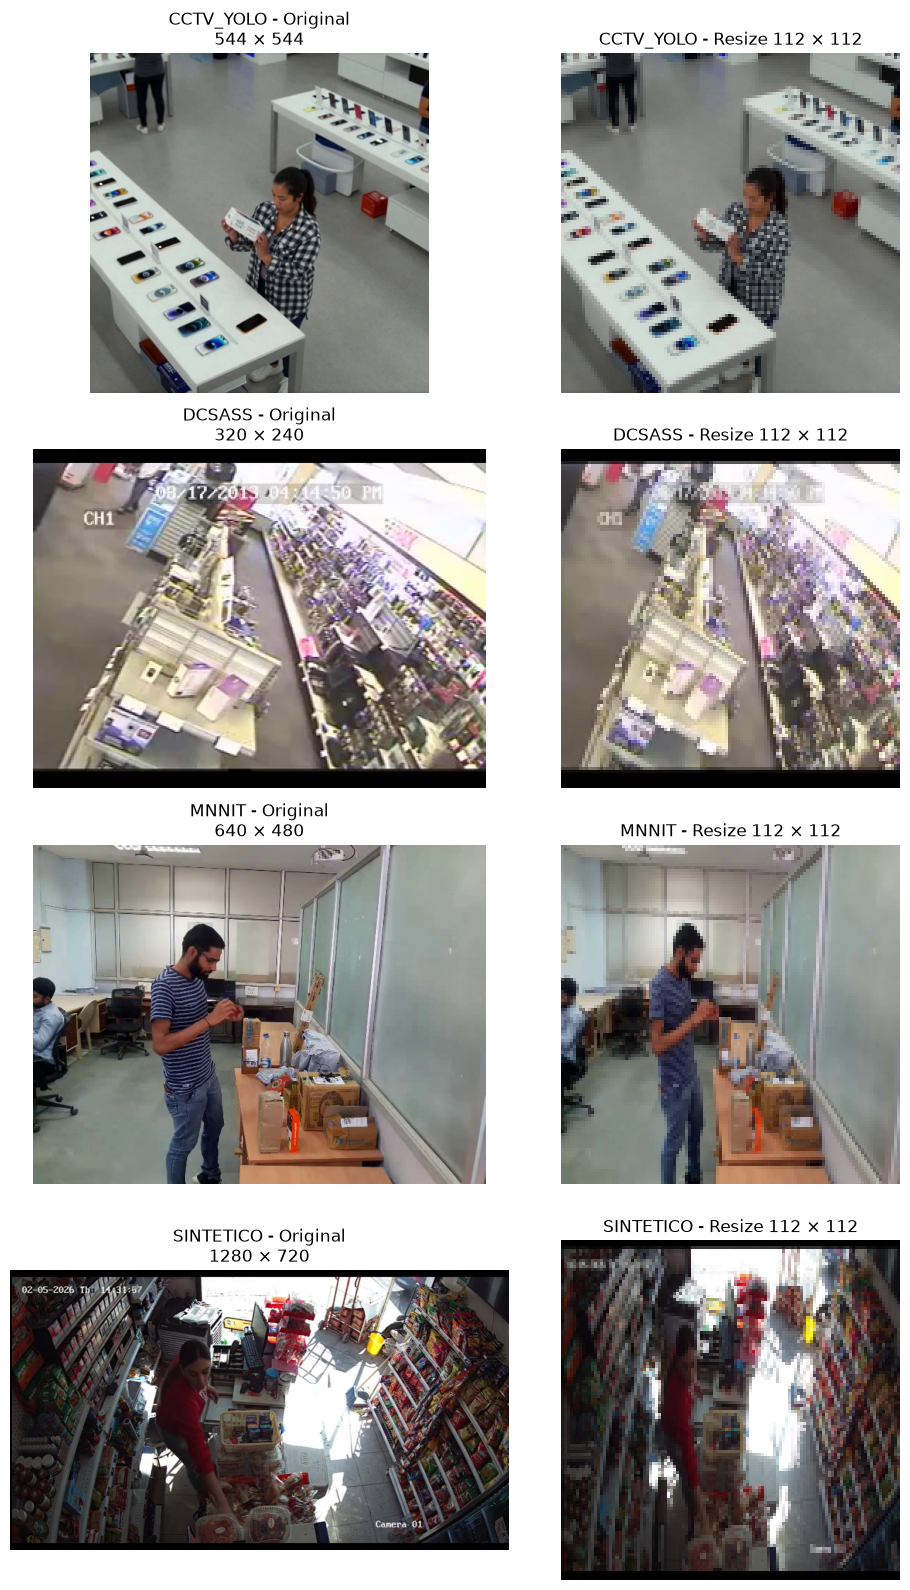

In [25]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10, 16)
)

for fila_idx, (_, fila) in enumerate(
    ejemplos_fuente.iterrows()
):
    dataset = fila["dataset"]
    nombre_clip = fila["nombre_clip"]

    ruta = CLIPS_DIR / nombre_clip

    cap = cv2.VideoCapture(str(ruta))
    ok, frame = cap.read()
    cap.release()

    if not ok:
        continue

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    frame_resize = cv2.resize(
        frame_rgb,
        (112, 112),
        interpolation=cv2.INTER_AREA
    )

    axes[fila_idx, 0].imshow(frame_rgb)
    axes[fila_idx, 0].set_title(
        f"{dataset} - Original\n"
        f"{frame_rgb.shape[1]} × "
        f"{frame_rgb.shape[0]}"
    )
    axes[fila_idx, 0].axis("off")

    axes[fila_idx, 1].imshow(frame_resize)
    axes[fila_idx, 1].set_title(
        f"{dataset} - Resize 112 × 112"
    )
    axes[fila_idx, 1].axis("off")

plt.tight_layout()
plt.show()

#### 2.2.7.1 Resultado de la validación visual

La inspección de ejemplos de las cuatro fuentes muestra que el redimensionamiento a 112 × 112 píxeles produce una pérdida visible de resolución y, en imágenes con relación de aspecto rectangular, cierta deformación geométrica. Sin embargo, en los ejemplos revisados permanecen reconocibles la persona, su postura y la estructura general de la escena.

Por esta razón, la transformación se considera aceptable para el experimento RGB baseline. La resolución de 112 × 112 permite mantener una entrada uniforme y un costo computacional reducido, aunque puede limitar la representación de objetos pequeños y movimientos finos de las manos.

Esta limitación se conservará como una variable experimental. Si el análisis de errores muestra falsos negativos asociados con productos pequeños, interacción mano-bolsillo o pérdida de detalle espacial, se evaluará posteriormente una mayor resolución o una estrategia basada en regiones de interés de la persona.

### 2.3 Normalización de valores RGB

Después de uniformar las dimensiones temporal y espacial, los valores de los píxeles deben transformarse a la representación numérica esperada por los modelos RGB.

Los frames obtenidos mediante OpenCV utilizan inicialmente valores enteros entre 0 y 255 y almacenan los canales en orden BGR. Antes de utilizarlos como entrada del modelo se realizará la siguiente transformación:

1. Conversión del orden de canales de BGR a RGB.
2. Conversión de los valores de píxel a tipo de punto flotante.
3. Escalamiento del intervalo 0–255 al intervalo 0–1.
4. Normalización de cada canal utilizando la media y desviación estándar definidas por los pesos preentrenados de la arquitectura utilizada.

Los valores de media y desviación estándar no se fijarán de manera arbitraria. Se utilizarán los parámetros asociados con la transformación oficial de los pesos preentrenados de cada modelo, con el fin de mantener consistencia entre el preprocesamiento de los datos y la distribución utilizada durante el preentrenamiento.

#### 2.3.1 Verificación de la representación original de los píxeles

Antes de aplicar la normalización se verificará la representación numérica de los frames obtenidos mediante OpenCV.

La auditoría considerará el tipo de dato, el número de canales y el rango de valores de los píxeles. OpenCV entrega normalmente imágenes de tres canales con valores enteros de 8 bits entre 0 y 255 y utiliza el orden de canales BGR.

Esta comprobación permitirá documentar el estado original de los datos antes de realizar la conversión a RGB, la transformación a punto flotante y el escalamiento al intervalo 0–1.

In [26]:
# Tomar un ejemplo real del dataset
ejemplo = ejemplos_fuente.iloc[0]

ruta = CLIPS_DIR / ejemplo["nombre_clip"]

cap = cv2.VideoCapture(str(ruta))
ok, frame_bgr = cap.read()
cap.release()

if not ok:
    raise RuntimeError("No fue posible leer el frame de ejemplo.")

print("Dataset:", ejemplo["dataset"])
print("Clip:", ejemplo["nombre_clip"])
print("Forma:", frame_bgr.shape)
print("Tipo de dato:", frame_bgr.dtype)
print("Valor mínimo:", frame_bgr.min())
print("Valor máximo:", frame_bgr.max())
print("Número de canales:", frame_bgr.shape[2])

Dataset: CCTV_YOLO
Clip: CCTV_YOLO__CCTV_001__CCTV_001.mp4
Forma: (544, 544, 3)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 255
Número de canales: 3


#### 2.3.2 Conversión BGR → RGB y escalamiento a [0,1]

Los frames obtenidos mediante OpenCV se encuentran en formato BGR y utilizan valores enteros entre 0 y 255.

Antes de utilizarlos como entrada de los modelos RGB, los canales se reorganizarán al formato RGB. Posteriormente, los valores se convertirán a `float32` y se dividirán entre 255 para obtener un intervalo numérico entre 0.0 y 1.0.

Esta transformación conserva la información visual del frame, pero modifica su representación numérica para hacerla compatible con las operaciones posteriores de normalización por canal y con el procesamiento mediante redes neuronales.

In [27]:
frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)

frame_float = frame_rgb.astype(
    np.float32
) / 255.0

print("Después de BGR → RGB y escalamiento")
print("-------------------------------------")
print("Forma:", frame_float.shape)
print("Tipo de dato:", frame_float.dtype)
print("Valor mínimo:", frame_float.min())
print("Valor máximo:", frame_float.max())
print("Número de canales:", frame_float.shape[2])

Después de BGR → RGB y escalamiento
-------------------------------------
Forma: (544, 544, 3)
Tipo de dato: float32
Valor mínimo: 0.0
Valor máximo: 1.0
Número de canales: 3


#### 2.3.3 Parámetros de normalización del baseline RGB

Los parámetros de normalización se tomaron de la documentación oficial de PyTorch para los pesos preentrenados `KINETICS400_V1` de R3D-18 y R(2+1)D-18.

Ambas arquitecturas utilizan:

- `mean = [0.43216, 0.394666, 0.37645]`
- `std = [0.22803, 0.22145, 0.216989]`
- entrada temporal de 16 frames
- tamaño espacial final de 112 × 112 píxeles

El preprocesamiento oficial de estos pesos aplica un redimensionamiento previo y posteriormente un recorte central de 112 × 112. En este proyecto se mantiene el tamaño final de 112 × 112 y los mismos parámetros de normalización por canal, pero se utiliza un redimensionamiento directo del frame completo para conservar todo el campo visual. Esta diferencia se documenta como una decisión específica del baseline.

Los parámetros descritos en esta sección corresponden específicamente al baseline basado en R3D-18 y R(2+1)D-18. Los experimentos posteriores con otras arquitecturas, como VideoMAE, utilizarán el preprocesamiento asociado con el checkpoint y los pesos preentrenados seleccionados para cada modelo.

De esta manera, el dataset consolidado, las etiquetas y la estrategia de partición se mantendrán comparables entre experimentos, mientras que las transformaciones de entrada se configurarán de acuerdo con los requerimientos de cada arquitectura.

In [28]:
MEAN_KINETICS400 = np.array(
    [0.43216, 0.394666, 0.37645],
    dtype=np.float32
)

STD_KINETICS400 = np.array(
    [0.22803, 0.22145, 0.216989],
    dtype=np.float32
)

print("Parámetros del baseline RGB")
print("---------------------------")
print("Mean:", MEAN_KINETICS400)
print("Std: ", STD_KINETICS400)

Parámetros del baseline RGB
---------------------------
Mean: [0.43216  0.394666 0.37645 ]
Std:  [0.22803  0.22145  0.216989]


#### 2.3.4 Aplicación de la normalización por canal

Para el baseline RGB, la normalización se aplica después de convertir el frame a RGB, redimensionarlo a 112 × 112 píxeles y escalar sus valores al intervalo 0–1.

Cada canal se transforma utilizando la media y desviación estándar correspondientes al preentrenamiento en Kinetics-400:

`valor_normalizado = (valor - media) / desviación_estándar`

Después de esta operación los valores ya no se encuentran necesariamente entre 0 y 1. La presencia de valores negativos y positivos es esperada, ya que cada canal queda expresado con respecto a la distribución utilizada durante el preentrenamiento del modelo.

**Nota**: Kinetics-400 se menciona porque constituye el conjunto utilizado para el preentrenamiento de los pesos empleados en el baseline, sus parámetros de preprocesamiento se conservan para mantener compatibilidad con dichos pesos durante el proceso de transferencia de aprendizaje.

In [29]:
# Conversión BGR → RGB
frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)

# Normalización espacial
frame_112 = cv2.resize(
    frame_rgb,
    (112, 112),
    interpolation=cv2.INTER_AREA
)

# Escalamiento a [0, 1]
frame_01 = frame_112.astype(
    np.float32
) / 255.0

# Normalización por canal
frame_normalizado = (
    frame_01 - MEAN_KINETICS400
) / STD_KINETICS400

print("Frame antes de normalización por canal")
print("----------------------------------------")
print("Forma:", frame_01.shape)
print("Tipo:", frame_01.dtype)
print("Mínimo:", frame_01.min())
print("Máximo:", frame_01.max())

print("\nFrame después de normalización por canal")
print("------------------------------------------")
print("Forma:", frame_normalizado.shape)
print("Tipo:", frame_normalizado.dtype)
print("Mínimo:", frame_normalizado.min())
print("Máximo:", frame_normalizado.max())

print("\nMedia resultante por canal RGB:")
print(frame_normalizado.mean(axis=(0, 1)))

Frame antes de normalización por canal
----------------------------------------
Forma: (112, 112, 3)
Tipo: float32
Mínimo: 0.0
Máximo: 0.8745098

Frame después de normalización por canal
------------------------------------------
Forma: (112, 112, 3)
Tipo: float32
Mínimo: -1.8951892
Máximo: 2.2049596

Media resultante por canal RGB:
[0.29005823 0.52296424 0.559571  ]


#### 2.3.5 Validación de la normalización RGB por fuente

In [30]:
resultados_rgb = []

for _, fila in ejemplos_fuente.iterrows():

    dataset = fila["dataset"]
    nombre_clip = fila["nombre_clip"]
    ruta = CLIPS_DIR / nombre_clip

    cap = cv2.VideoCapture(str(ruta))
    ok, frame_bgr_fuente = cap.read()
    cap.release()

    if not ok:
        resultados_rgb.append({
            "dataset": dataset,
            "forma_final": None,
            "tipo_final": None,
            "min_normalizado": None,
            "max_normalizado": None,
            "procesamiento_ok": False
        })
        continue

    # BGR → RGB
    frame_rgb_fuente = cv2.cvtColor(
        frame_bgr_fuente,
        cv2.COLOR_BGR2RGB
    )

    # Resize
    frame_112_fuente = cv2.resize(
        frame_rgb_fuente,
        (112, 112),
        interpolation=cv2.INTER_AREA
    )

    # Escalamiento [0,1]
    frame_01_fuente = (
        frame_112_fuente.astype(np.float32)
        / 255.0
    )

    # Normalización por canal
    frame_norm_fuente = (
        frame_01_fuente - MEAN_KINETICS400
    ) / STD_KINETICS400

    resultados_rgb.append({
        "dataset": dataset,
        "forma_final": str(frame_norm_fuente.shape),
        "tipo_final": str(frame_norm_fuente.dtype),
        "min_normalizado": round(
            float(frame_norm_fuente.min()), 3
        ),
        "max_normalizado": round(
            float(frame_norm_fuente.max()), 3
        ),
        "procesamiento_ok": True
    })


df_validacion_rgb = pd.DataFrame(resultados_rgb)

df_validacion_rgb

,dataset,forma_final,tipo_final,min_normalizado,max_normalizado,procesamiento_ok
0,CCTV_YOLO,"(112, 112, 3)",float32,-1.895,2.205,True
1,DCSASS,"(112, 112, 3)",float32,-1.895,2.874,True
2,MNNIT,"(112, 112, 3)",float32,-1.895,2.548,True
3,SINTETICO,"(112, 112, 3)",float32,-1.895,2.874,True


#### 2.3.6 Pipeline integrado de preprocesamiento RGB

Las transformaciones temporal, espacial y numérica fueron evaluadas individualmente en las secciones anteriores. Para comprobar que estas decisiones pueden ejecutarse como un único proceso reproducible, se integraron en una función de preprocesamiento aplicada directamente a un archivo de video.

El pipeline del baseline realiza las siguientes operaciones:

1. Obtiene el número de frames del clip.
2. Selecciona 16 índices distribuidos uniformemente a lo largo de toda la secuencia.
3. Decodifica únicamente los frames seleccionados.
4. Convierte cada frame de BGR a RGB.
5. Redimensiona el frame completo a 112 × 112 píxeles.
6. Convierte los valores a `float32` y los escala al intervalo [0,1].
7. Aplica la normalización por canal correspondiente a los pesos preentrenados en Kinetics-400.
8. Reordena las dimensiones desde `(T, H, W, C)` hasta `(C, T, H, W)`.

El resultado esperado para cada clip del baseline es una representación de forma `(3, 16, 112, 112)`. Esta estructura contiene tres canales RGB, 16 muestras temporales y una resolución espacial uniforme de 112 × 112 píxeles.

In [31]:
import numpy as np
import cv2


# Parámetros del baseline RGB preentrenado en Kinetics-400
MEAN_KINETICS400 = np.array(
    [0.43216, 0.394666, 0.37645],
    dtype=np.float32
)

STD_KINETICS400 = np.array(
    [0.22803, 0.22145, 0.216989],
    dtype=np.float32
)


def preprocesar_clip_rgb(
    ruta_video,
    frames_objetivo=16,
    tamano_final=(112, 112)
):
    """
    Preprocesa un clip para el baseline RGB.

    Retorna
    -------
    clip_cthw : np.ndarray
        Arreglo float32 con forma (C, T, H, W).

    indices : np.ndarray
        Índices temporales seleccionados.
    """

    captura = cv2.VideoCapture(str(ruta_video))

    if not captura.isOpened():
        raise RuntimeError(
            f"No se pudo abrir el video: {ruta_video}"
        )

    num_frames = int(
        captura.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if num_frames < frames_objetivo:
        captura.release()
        raise ValueError(
            f"El clip contiene {num_frames} frames; "
            f"se requieren al menos {frames_objetivo}."
        )

    # Muestreo temporal uniforme
    indices = np.linspace(
        0,
        num_frames - 1,
        frames_objetivo
    )

    indices = np.round(
        indices
    ).astype(int)

    if len(np.unique(indices)) != frames_objetivo:
        captura.release()
        raise ValueError(
            "El muestreo temporal produjo índices repetidos."
        )

    frames_procesados = []

    posicion_objetivo = 0
    indice_frame = 0

    while posicion_objetivo < len(indices):

        ok, frame_bgr = captura.read()

        if not ok:
            break

        if indice_frame == indices[posicion_objetivo]:

            # BGR → RGB
            frame_rgb = cv2.cvtColor(
                frame_bgr,
                cv2.COLOR_BGR2RGB
            )

            # Normalización espacial
            frame_112 = cv2.resize(
                frame_rgb,
                tamano_final,
                interpolation=cv2.INTER_AREA
            )

            # Escalamiento a [0,1]
            frame_01 = (
                frame_112.astype(np.float32)
                / 255.0
            )

            # Normalización por canal
            frame_norm = (
                frame_01 - MEAN_KINETICS400
            ) / STD_KINETICS400

            frames_procesados.append(
                frame_norm.astype(
                    np.float32,
                    copy=False
                )
            )

            posicion_objetivo += 1

        indice_frame += 1

    captura.release()

    if len(frames_procesados) != frames_objetivo:
        raise RuntimeError(
            f"Se obtuvieron {len(frames_procesados)} "
            f"frames de {frames_objetivo} esperados "
            f"en {ruta_video}."
        )

    # (T, H, W, C)
    clip_thwc = np.stack(
        frames_procesados,
        axis=0
    )

    # (T, H, W, C) → (C, T, H, W)
    clip_cthw = np.transpose(
        clip_thwc,
        (3, 0, 1, 2)
    )

    return clip_cthw, indices

In [32]:
# Validación end-to-end sobre un clip de cada fuente

ejemplos_pipeline = (
    df.groupby("dataset")
    .first()
    .reset_index()
    [["dataset", "nombre_clip"]]
)

resultados_pipeline = []

for _, fila in ejemplos_pipeline.iterrows():

    dataset = fila["dataset"]
    nombre_clip = fila["nombre_clip"]
    ruta = CLIPS_DIR / nombre_clip

    clip_cthw, indices = preprocesar_clip_rgb(
        ruta
    )

    resultados_pipeline.append({
        "dataset": dataset,
        "nombre_clip": nombre_clip,
        "forma_final": str(clip_cthw.shape),
        "tipo": str(clip_cthw.dtype),
        "frames": clip_cthw.shape[1],
        "primer_indice": int(indices[0]),
        "ultimo_indice": int(indices[-1]),
        "valores_finitos": bool(
            np.isfinite(clip_cthw).all()
        ),
        "min": round(
            float(clip_cthw.min()),
            3
        ),
        "max": round(
            float(clip_cthw.max()),
            3
        )
    })

df_pipeline = pd.DataFrame(
    resultados_pipeline
)

display(df_pipeline)


# Invariantes del pipeline
assert len(df_pipeline) == 4

assert (
    df_pipeline["forma_final"]
    == "(3, 16, 112, 112)"
).all()

assert (
    df_pipeline["tipo"]
    == "float32"
).all()

assert (
    df_pipeline["frames"]
    == 16
).all()

assert (
    df_pipeline["valores_finitos"]
).all()

print(
    "\nPipeline integrado validado "
    "correctamente en las cuatro fuentes."
)

,dataset,nombre_clip,forma_final,tipo,frames,primer_indice,ultimo_indice,valores_finitos,min,max
0,CCTV_YOLO,CCTV_YOLO__CCTV_001__CCTV_001.mp4,"(3, 16, 112, 112)",float32,16,0,95,True,-1.895,2.277
1,DCSASS,DCSASS__Shoplifting001_x264__Shoplifting001_x264_0.mp4,"(3, 16, 112, 112)",float32,16,0,119,True,-1.895,2.874
2,MNNIT,MNNIT__shoplifting-1__MNNIT_001.mp4,"(3, 16, 112, 112)",float32,16,0,119,True,-1.895,2.783
3,SINTETICO,SINTETICO__S_001__SC_001.mp4,"(3, 16, 112, 112)",float32,16,0,95,True,-1.895,2.874



Pipeline integrado validado correctamente en las cuatro fuentes.


#### 2.3.7 Resultado de la validación integrada

La ejecución del pipeline completo sobre ejemplos provenientes de CCTV_YOLO, DCSASS, MNNIT y SINTETICO produjo en todos los casos una representación de forma `(3, 16, 112, 112)` y tipo `float32`.

Los 16 frames seleccionados cubren toda la secuencia temporal disponible: el primer índice corresponde al frame 0 y el último índice coincide con el final del clip utilizado en cada ejemplo. Las diferencias entre índices finales reflejan la cantidad original de frames de cada archivo y no una diferencia en la dimensión temporal final, que permanece fija en 16 frames.

Todos los valores obtenidos son finitos. Después de la normalización con los parámetros de Kinetics-400 se observan valores negativos y positivos, comportamiento esperado porque los canales quedan expresados con respecto a la media y desviación estándar utilizadas durante el preentrenamiento.

Esta validación confirma que las decisiones definidas de forma individual para muestreo temporal, redimensionamiento espacial y transformación RGB pueden ejecutarse como un único pipeline reproducible sobre las cuatro fuentes del dataset consolidado.

### 2.4 Conclusiones de normalización y transformación

La etapa de normalización permitió definir una representación uniforme de los clips para el experimento RGB baseline.

En la dimensión temporal, cada clip se representa mediante 16 frames distribuidos uniformemente a lo largo de toda su duración física. Esta estrategia mantiene cobertura del inicio al final de la secuencia sin modificar los archivos originales ni imponer una duración física idéntica. La auditoría confirmó que los 987 clips contienen suficientes frames para obtener 16 índices únicos, por lo que no es necesario utilizar padding temporal ni repetición de cuadros en el dataset actual.

En la dimensión espacial, cada frame completo se redimensiona a 112 × 112 píxeles. Esta decisión conserva todo el campo visual a costa de cierta deformación geométrica en las fuentes cuya relación de aspecto original no es cuadrada. La inspección visual mostró que la persona, su postura y la estructura general de la escena permanecen reconocibles, aunque la reducción espacial puede afectar objetos pequeños o movimientos finos de las manos.

Para la representación numérica, los frames se convierten de BGR a RGB, se transforman a `float32`, se escalan al intervalo [0,1] y posteriormente se normalizan por canal utilizando la media y desviación estándar correspondientes a los pesos preentrenados en Kinetics-400 empleados por R3D-18 y R(2+1)D-18.

El pipeline integrado del baseline queda definido como:

`clip → muestreo uniforme de 16 frames → RGB → resize 112 × 112 → float32 → [0,1] → normalización por canal → (C,T,H,W)`

La implementación completa fue validada sobre ejemplos de las cuatro fuentes y produjo en todos los casos una representación `float32` de forma `(3, 16, 112, 112)`, con valores finitos y cobertura temporal desde el primer hasta el último frame disponible.

Esta representación constituye la entrada preparada para los experimentos RGB baseline. Durante el entrenamiento, varios clips podrán agruparse posteriormente en batches con forma `(N, C, T, H, W)`, donde `N` corresponde al número de clips procesados conjuntamente.

Las transformaciones descritas corresponden específicamente al baseline basado en R3D-18 y R(2+1)D-18. Los experimentos posteriores con arquitecturas como VideoMAE deberán utilizar el preprocesamiento correspondiente a sus propios pesos preentrenados, manteniendo comparables el dataset, las etiquetas y la estrategia de evaluación.

## 3. Selección y extracción de características

En datos de video, la selección y extracción de características debe considerar la estructura temporal y espacial de la información.

Para este proyecto, la reducción de complejidad se realiza principalmente mediante la selección de clips elegibles, el muestreo temporal de 16 frames por clip y la normalización espacial a 112 × 112 píxeles. Estas decisiones reducen la cantidad de información procesada sin eliminar completamente la secuencia temporal necesaria para reconocer la acción de ocultamiento.

Variables utilizadas para control y auditoría, como `dataset`, `duracion_real_s` o los indicadores de preparación, no se utilizarán como entradas predictivas del modelo. Su propósito es apoyar la trazabilidad, el análisis de sesgo y la definición de los experimentos.

La extracción de representaciones espacio-temporales se realizará posteriormente mediante las capas internas de los modelos de reconocimiento de acciones. Por esta razón, no se aplicará como estrategia principal una reducción dimensional directa, como PCA, sobre los píxeles RGB, ya que podría eliminar relaciones espaciales y temporales relevantes para la acción.

### 3.1 Selección de clips elegibles para el modelo

El dataset consolidado contiene 987 clips y se conserva como conjunto de referencia para análisis, trazabilidad y auditoría. Sin embargo, el conjunto utilizado para los experimentos supervisados debe incluir únicamente observaciones cuya etiqueta corresponda de forma clara con alguna de las dos clases del problema.

Para el problema binario se consideran elegibles los clips etiquetados como `sin_ocultamiento` u `ocultamiento`. Los registros con etiquetas ambiguas se mantienen en el dataset consolidado para fines de análisis, pero se excluyen del entrenamiento y evaluación supervisados.

La selección también conserva las validaciones técnicas realizadas previamente, incluyendo disponibilidad del archivo físico, capacidad de decodificación y, para DCSASS, pertenencia al subconjunto registrado y revisado en `dataset_manifest_todos.csv`.

Esta separación permite mantener un dataset consolidado amplio para auditoría y definir un subconjunto elegible para los experimentos supervisados, con menor riesgo de introducir ruido de etiqueta.

In [33]:
df_modelo = df[
    df["elegible_modelo_binario"] == True
].copy()

print("Selección de clips elegibles")
print("----------------------------")
print(f"Dataset consolidado:       {len(df)}")
print(f"Clips elegibles binarios:  {len(df_modelo)}")
print(f"Clips excluidos:           {len(df) - len(df_modelo)}")

print("\nDistribución por clase:")
print(
    df_modelo["etiqueta"]
    .value_counts()
)

print("\nDistribución por fuente:")
print(
    df_modelo["dataset"]
    .value_counts()
)

Selección de clips elegibles
----------------------------
Dataset consolidado:       987
Clips elegibles binarios:  985
Clips excluidos:           2

Distribución por clase:
etiqueta
sin_ocultamiento    795
ocultamiento        190
Name: count, dtype: int64

Distribución por fuente:
dataset
DCSASS       783
MNNIT        182
SINTETICO     12
CCTV_YOLO      8
Name: count, dtype: int64


### 3.2 Selección temporal de frames

La selección temporal de 16 frames por clip cumple además una función de reducción de complejidad.

Los videos consolidados contienen entre 30 y 150 frames, dependiendo de su duración y frecuencia de cuadros. Procesar todos los cuadros disponibles incrementaría el uso de memoria y el tiempo de entrenamiento, además de introducir una cantidad considerable de información redundante entre frames consecutivos.

Por esta razón, para el baseline RGB se seleccionan 16 frames distribuidos uniformemente a lo largo de cada clip. Esta estrategia conserva cobertura sobre la secuencia completa y reduce la cantidad de información temporal procesada por el modelo.

La selección de 16 frames cumple una doble función: normaliza la dimensión temporal de entrada y reduce la cantidad de información procesada mediante submuestreo temporal. En este contexto se considera una estrategia de reducción de la representación de entrada; las características espacio-temporales utilizadas para la clasificación serán extraídas posteriormente por el modelo.

In [34]:
# Asociar los clips elegibles con su número real de frames
df_reduccion_temporal = df_modelo[
    ["nombre_clip", "dataset"]
].merge(
    df_temporal[
        ["nombre_clip", "num_frames"]
    ],
    on="nombre_clip",
    how="left"
)

FRAMES_SELECCIONADOS = 16

df_reduccion_temporal["pct_frames_conservados"] = (
    FRAMES_SELECCIONADOS
    / df_reduccion_temporal["num_frames"]
    * 100
)

resumen_reduccion_temporal = (
    df_reduccion_temporal
    .groupby("dataset")
    .agg(
        clips=("nombre_clip", "count"),
        frames_min=("num_frames", "min"),
        frames_max=("num_frames", "max"),
        frames_mediana=("num_frames", "median"),
        pct_conservado_min=("pct_frames_conservados", "min"),
        pct_conservado_max=("pct_frames_conservados", "max"),
        pct_conservado_mediana=("pct_frames_conservados", "median"),
    )
    .reset_index()
)

resumen_reduccion_temporal.round(2)

,dataset,clips,frames_min,frames_max,frames_mediana,pct_conservado_min,pct_conservado_max,pct_conservado_mediana
0,CCTV_YOLO,8,96,96,96.0,16.67,16.67,16.67
1,DCSASS,783,30,150,60.0,10.67,53.33,26.67
2,MNNIT,182,120,120,120.0,13.33,13.33,13.33
3,SINTETICO,12,96,96,96.0,16.67,16.67,16.67


#### 3.2.1 Resultado de la reducción temporal

La selección de 16 frames reduce de manera importante la cantidad de información temporal procesada por el baseline.

CCTV_YOLO y SINTETICO conservan aproximadamente el 16.67% de sus frames originales, mientras que MNNIT conserva alrededor del 13.33%. En DCSASS, debido a que los clips tienen duraciones entre 1 y 5 segundos, la proporción conservada varía entre 10.67% y 53.33%, con una mediana de 26.67%.

La proporción de frames retenidos no es uniforme entre clips. Esta diferencia es esperada, ya que el objetivo del muestreo es producir una representación temporal de tamaño fijo y mantener cobertura sobre la secuencia completa, no conservar el mismo porcentaje de cuadros originales en todos los videos.

La reducción temporal disminuye redundancia entre frames consecutivos, uso de memoria y costo de procesamiento, manteniendo 16 observaciones distribuidas a lo largo de cada clip.

### 3.3 Reducción espacial de la representación

La normalización a 112 × 112 píxeles también funciona como una estrategia de reducción de complejidad espacial.

Las resoluciones originales del dataset varían desde 320 × 240 hasta 1920 × 1080 píxeles. Después de la transformación, cada frame utilizado por el baseline contiene 12,544 píxeles, independientemente de su fuente de origen.

Esta reducción disminuye la cantidad de información procesada por frame y permite reducir el uso de memoria y el costo computacional durante el entrenamiento.

La reducción espacial implica también una pérdida de detalle. Esta limitación es especialmente relevante para objetos pequeños o interacciones finas entre manos, productos y zonas de ocultamiento. Por esta razón, la resolución de 112 × 112 se mantiene como una decisión específica del baseline y deberá revisarse posteriormente mediante el análisis de errores del modelo.

In [35]:
PIXELS_FINAL = 112 * 112

reduccion_espacial = tabla_resoluciones.copy()

reduccion_espacial["pixels_originales"] = (
    reduccion_espacial["ancho"]
    * reduccion_espacial["alto"]
)

reduccion_espacial["pixels_finales"] = PIXELS_FINAL

reduccion_espacial["pct_pixels_conservados"] = (
    reduccion_espacial["pixels_finales"]
    / reduccion_espacial["pixels_originales"]
    * 100
).round(2)

reduccion_espacial["factor_reduccion"] = (
    reduccion_espacial["pixels_originales"]
    / reduccion_espacial["pixels_finales"]
).round(1)

reduccion_espacial[
    [
        "dataset",
        "ancho",
        "alto",
        "clips",
        "pixels_originales",
        "pixels_finales",
        "pct_pixels_conservados",
        "factor_reduccion"
    ]
]

,dataset,ancho,alto,clips,pixels_originales,pixels_finales,pct_pixels_conservados,factor_reduccion
0,CCTV_YOLO,544,544,8,295936,12544,4.24,23.6
1,DCSASS,320,240,783,76800,12544,16.33,6.1
2,MNNIT,640,480,174,307200,12544,4.08,24.5
3,MNNIT,1920,1080,8,2073600,12544,0.60,165.3
4,SINTETICO,1280,720,13,921600,12544,1.36,73.5
5,SINTETICO,1366,768,1,1049088,12544,1.20,83.6


#### 3.3.1 Resultado de la reducción espacial

La transformación a 112 × 112 píxeles reduce de forma importante la cantidad de información espacial procesada por el baseline.

En DCSASS, cuya resolución original es 320 × 240, la representación final contiene aproximadamente el 16.33% del número original de píxeles. En resoluciones mayores la reducción es más pronunciada: los videos MNNIT de 1920 × 1080 se reducen a aproximadamente el 0.60% del número original de píxeles, mientras que los videos SINTETICO de 1280 × 720 conservan aproximadamente el 1.36%.

Estos porcentajes representan reducción en cantidad de píxeles y no pérdida equivalente de campo visual, ya que el resize directo mantiene representada la escena completa dentro de la imagen final de 112 × 112.

La reducción espacial disminuye significativamente el costo computacional y el consumo de memoria, pero también puede eliminar detalle fino. Por esta razón, el análisis de errores del baseline deberá revisar especialmente casos con productos pequeños, movimientos de manos o zonas de ocultamiento poco visibles.

#### 3.3.2 Reducción conjunta de la representación de entrada

La reducción temporal y espacial actúan conjuntamente sobre la cantidad de valores que debe procesar el modelo. Para cuantificar este efecto se comparó el tamaño aproximado de la representación RGB original de cada clip con la representación uniforme utilizada por el baseline.

El número de valores de un clip original se estimó mediante:

`frames × alto × ancho × 3 canales`

Después del preprocesamiento, todos los clips quedan representados mediante:

`16 × 112 × 112 × 3 = 602,112 valores`

La reducción varía según las características originales de cada fuente. CCTV_YOLO conserva aproximadamente el 0.71% de los valores originales, equivalente a una reducción mediana de 141.55 veces. DCSASS conserva una mediana de 4.36%, con una reducción mediana de 22.96 veces; la diferencia respecto de las demás fuentes se explica por su menor resolución original y por la variación en duración de sus clips.

En MNNIT la representación preparada conserva una mediana de 0.54% de los valores originales, equivalente a una reducción de 183.67 veces. El porcentaje mínimo observado, 0.08%, corresponde a los clips de mayor resolución presentes en esta fuente. En SINTETICO se conserva una mediana de 0.23%, con una reducción aproximada de 440.82 veces.

Estos porcentajes cuantifican la reducción del número de valores procesados y no la proporción de información semántica conservada. El objetivo del muestreo temporal y del redimensionamiento espacial es reducir redundancia, memoria y costo computacional mientras se mantiene una representación estructurada de la secuencia completa.

La representación final conserva la organización espacio-temporal requerida por el baseline y evita aplanar los clips antes de que los modelos de reconocimiento de acciones extraigan sus características.

In [36]:
# Reducción conjunta temporal + espacial

FINAL_T = 16
FINAL_H = 112
FINAL_W = 112
CANALES = 3

VALORES_FINALES = (
    FINAL_T
    * FINAL_H
    * FINAL_W
    * CANALES
)

df_complejidad = (
    df[
        ["nombre_clip", "dataset"]
    ]
    .merge(
        df_temporal[
            ["nombre_clip", "num_frames"]
        ],
        on="nombre_clip",
        how="left",
        validate="one_to_one"
    )
    .merge(
        df_espacial[
            ["nombre_clip", "ancho", "alto"]
        ],
        on="nombre_clip",
        how="left",
        validate="one_to_one"
    )
)

df_complejidad["valores_originales"] = (
    df_complejidad["num_frames"]
    * df_complejidad["ancho"]
    * df_complejidad["alto"]
    * CANALES
)

df_complejidad["valores_finales"] = (
    VALORES_FINALES
)

df_complejidad["porcentaje_conservado"] = (
    100
    * df_complejidad["valores_finales"]
    / df_complejidad["valores_originales"]
)

df_complejidad["factor_reduccion"] = (
    df_complejidad["valores_originales"]
    / df_complejidad["valores_finales"]
)

resumen_complejidad = (
    df_complejidad
    .groupby("dataset")
    .agg(
        clips=("nombre_clip", "size"),
        porcentaje_min=(
            "porcentaje_conservado",
            "min"
        ),
        porcentaje_mediana=(
            "porcentaje_conservado",
            "median"
        ),
        porcentaje_max=(
            "porcentaje_conservado",
            "max"
        ),
        factor_reduccion_mediano=(
            "factor_reduccion",
            "median"
        )
    )
    .reset_index()
)

columnas_redondeo = [
    "porcentaje_min",
    "porcentaje_mediana",
    "porcentaje_max",
    "factor_reduccion_mediano"
]

resumen_complejidad[
    columnas_redondeo
] = resumen_complejidad[
    columnas_redondeo
].round(2)

print(
    "Valores finales por clip:",
    VALORES_FINALES
)

display(resumen_complejidad)

Valores finales por clip: 602112


,dataset,clips,porcentaje_min,porcentaje_mediana,porcentaje_max,factor_reduccion_mediano
0,CCTV_YOLO,8,0.71,0.71,0.71,141.55
1,DCSASS,783,1.74,4.36,8.71,22.96
2,MNNIT,182,0.08,0.54,0.54,183.67
3,SINTETICO,14,0.20,0.23,0.23,440.82


### 3.4 Selección de variables de control y exclusión de características sesgadas

El dataset consolidado contiene variables necesarias para trazabilidad, auditoría y preparación, pero no todas deben utilizarse como características predictivas.

Variables como `dataset`, `duracion_real_s`, `cumple_4s`, `requiere_normalizacion_temporal`, `video_id`, `clip_id` y `nombre_clip` se conservarán como información de control. Estas variables permiten analizar diferencias entre fuentes, reconstruir el origen de cada observación, definir particiones experimentales y revisar errores.

Sin embargo, no se utilizarán como entradas del modelo RGB, ya que no representan directamente la acción de ocultamiento y algunas están asociadas con la fuente de los datos o con decisiones de preprocesamiento. Su inclusión podría facilitar aprendizaje de atajos y reducir la capacidad de generalización hacia nuevas condiciones de captura.

La entrada predictiva del baseline se limitará a la información visual normalizada de los clips, mientras que las variables tabulares de control se utilizarán exclusivamente para análisis, partición y evaluación.

#### 3.4.1 Clasificación de columnas por función

In [37]:
columnas_target = [
    "etiqueta",
    "clase_binaria"
]

columnas_control = [
    "dataset",
    "video_id",
    "video_origen",
    "clip_id",
    "inicio_s",
    "fin_s",
    "persona_id",
    "evento_id",
    "nota",
    "nombre_clip",
    "duracion_real_s",
    "duracion_objetivo_s",
    "diferencia_vs_4s",
    "cumple_4s",
    "requiere_normalizacion_temporal",
    "elegible_modelo_binario",
    "motivo_no_elegible"
]

columnas_tabulares_predictivas = []

columnas_clasificadas = (
    columnas_target
    + columnas_control
    + columnas_tabulares_predictivas
)

columnas_sin_clasificar = sorted(
    set(df.columns) - set(columnas_clasificadas)
)

columnas_repetidas = (
    len(columnas_clasificadas)
    - len(set(columnas_clasificadas))
)

print("Clasificación de columnas")
print("-------------------------")
print(f"Columnas totales en df:             {len(df.columns)}")
print(f"Variables target:                    {len(columnas_target)}")
print(f"Variables de control:                {len(columnas_control)}")
print(
    f"Variables tabulares predictivas:     "
    f"{len(columnas_tabulares_predictivas)}"
)
print(
    f"Columnas sin clasificar:             "
    f"{len(columnas_sin_clasificar)}"
)
print(
    f"Columnas repetidas entre categorías: "
    f"{columnas_repetidas}"
)

print("\nTarget:")
print(columnas_target)

print("\nEntrada predictiva del baseline:")
print(
    "Tensor visual normalizado: "
    "16 frames × 112 × 112 × 3 canales"
)

print("\nColumnas sin clasificar:")
print(columnas_sin_clasificar)

Clasificación de columnas
-------------------------
Columnas totales en df:             19
Variables target:                    2
Variables de control:                17
Variables tabulares predictivas:     0
Columnas sin clasificar:             0
Columnas repetidas entre categorías: 0

Target:
['etiqueta', 'clase_binaria']

Entrada predictiva del baseline:
Tensor visual normalizado: 16 frames × 112 × 112 × 3 canales

Columnas sin clasificar:
[]


### 3.5 Extracción automática de características espacio-temporales

El baseline RGB no utilizará características visuales diseñadas manualmente. La extracción de representaciones se realizará mediante las capas internas de los modelos de reconocimiento de acciones R3D-18 y R(2+1)D-18.

La entrada de cada clip estará formada por 16 frames normalizados espacial y numéricamente. A partir de esta secuencia, las capas del modelo extraerán progresivamente representaciones relacionadas con apariencia, formas, movimiento y relaciones espacio-temporales.

Los pesos preentrenados en Kinetics-400 proporcionan un punto de partida con representaciones aprendidas previamente sobre acciones humanas. Mediante transferencia de aprendizaje, estas representaciones se ajustarán posteriormente al problema específico de clasificación entre `sin_ocultamiento` y `ocultamiento`.

Este enfoque reduce la necesidad de definir manualmente variables visuales y permite que el modelo aprenda combinaciones de características espaciales y temporales directamente a partir de los clips seleccionados.

### 3.6 Justificación de no aplicar PCA sobre los píxeles RGB

Aunque PCA es una técnica común para reducir dimensionalidad en datasets tabulares, no se utilizará directamente sobre los píxeles RGB de los clips.

Los datos de video contienen estructura espacial y temporal. La posición relativa de los píxeles dentro de cada frame y la relación entre frames consecutivos aportan información necesaria para reconocer una acción. Aplicar PCA sobre una representación aplanada del video podría eliminar o mezclar parte de estas relaciones antes de que el modelo pueda analizarlas.

Los modelos R3D-18 y R(2+1)D-18 están diseñados para extraer automáticamente características espacio-temporales a partir de tensores de video. Además, sus pesos preentrenados fueron obtenidos utilizando entradas con esta estructura, por lo que conservarla resulta consistente con el enfoque de transferencia de aprendizaje utilizado en el baseline.

La reducción de complejidad se realiza mediante la selección de 16 frames y la reducción espacial a 112 × 112 píxeles, manteniendo la organización del video. PCA podrá evaluarse posteriormente sobre embeddings o representaciones internas del modelo con fines exploratorios o de visualización, pero no como transformación principal de los píxeles RGB.

### 3.7 Conclusiones de selección y extracción de características

La selección y extracción de características se adaptó a la naturaleza espacio-temporal de los datos de video.

A partir del dataset consolidado de 987 clips se seleccionaron 985 observaciones elegibles para el problema binario, excluyendo los casos ambiguos del entrenamiento y evaluación supervisados.

La complejidad temporal se redujo mediante la selección uniforme de 16 frames por clip y la complejidad espacial mediante el redimensionamiento a 112 × 112 píxeles. El resultado es una representación uniforme de 602,112 valores RGB por clip. Dependiendo de la fuente, esta transformación representa reducciones medianas de aproximadamente 22.96 a 440.82 veces respecto de la cantidad de valores presentes en los videos originales.

Estas operaciones reducen memoria, volumen de procesamiento y costo computacional sin eliminar la estructura temporal y espacial que utilizarán los modelos. La reducción obtenida debe interpretarse como una disminución de la representación numérica y no como una medida de la información semántica conservada.

Las variables tabulares asociadas con fuente, duración, identificadores y decisiones de preparación se conservarán únicamente para trazabilidad, auditoría, partición y análisis de sesgo. No se utilizarán como características predictivas del baseline, con el fin de reducir el riesgo de aprendizaje de atajos relacionados con la procedencia de los datos.

La extracción de características espacio-temporales se realizará automáticamente mediante R3D-18 y R(2+1)D-18, utilizando transferencia de aprendizaje a partir de pesos preentrenados en Kinetics-400. Estas arquitecturas recibirán como entrada la representación preparada con forma `(C,T,H,W)` y aprenderán características relacionadas con apariencia, movimiento y relaciones espacio-temporales.

No se aplicará PCA directamente sobre los píxeles RGB, ya que se busca preservar la organización espacial y temporal que estas arquitecturas están diseñadas para explotar. PCA podría evaluarse posteriormente sobre embeddings aprendidos con fines exploratorios o de visualización.

Con estas decisiones, cada clip elegible queda preparado como una secuencia visual uniforme, con una reducción considerable de complejidad y con las variables de control separadas de la información utilizada directamente por el modelo.

## 4. Conclusiones de Data Preparation dentro de CRISP-ML(Q)

La etapa de Data Preparation permitió transformar un conjunto heterogéneo de videos provenientes de distintas fuentes en una base estructurada, trazable y técnicamente validada para los experimentos de reconocimiento de ocultamiento.

El dataset consolidado contiene 987 clips provenientes de cuatro fuentes RGB. Este conjunto se conserva como referencia para análisis y auditoría. Después de aplicar los criterios de elegibilidad del problema binario, 985 clips quedan disponibles para los experimentos supervisados de `ocultamiento` y `sin_ocultamiento`, mientras que los casos ambiguos permanecen registrados pero se excluyen del entrenamiento y evaluación supervisados.

La preparación incluyó controles de integridad y trazabilidad entre manifiestos, archivos físicos y metadatos derivados. También se verificaron la capacidad de decodificación, duración, cantidad de frames, dimensiones espaciales, etiquetas y procedencia de los clips. En DCSASS, la revisión visual permitió además distinguir entre fragmentos pertinentes para las clases del proyecto y segmentos que, aunque pertenecieran a videos asociados con Shoplifting, no contenían información útil para clasificar la acción objetivo.

Durante el análisis se identificaron diferencias entre las fuentes en duración, frecuencia de cuadros, resolución, relación de aspecto y distribución de clases. También se observaron dependencias entre clips provenientes de un mismo video y asociaciones potenciales entre características técnicas y la fuente o la etiqueta. Estas variables se conservaron como información de control para trazabilidad, partición experimental y análisis de sesgo, pero se excluyen de la entrada predictiva del modelo RGB.

Para el baseline se definió una representación uniforme mediante muestreo temporal de 16 frames, redimensionamiento a 112 × 112 píxeles, conversión a RGB, escalamiento a `float32` en el intervalo [0,1] y normalización por canal compatible con los pesos preentrenados en Kinetics-400 utilizados por R3D-18 y R(2+1)D-18. El pipeline integrado fue validado sobre las cuatro fuentes y produce una representación final de forma `(3, 16, 112, 112)` con valores finitos.

La combinación del submuestreo temporal y la reducción espacial disminuye de forma considerable la complejidad de la entrada. Cada clip preparado contiene 602,112 valores RGB y, dependiendo de la fuente, la reducción mediana respecto de la representación original se encuentra aproximadamente entre 22.96 y 440.82 veces. Esta reducción disminuye memoria y costo de procesamiento manteniendo explícitamente la estructura temporal y espacial requerida por los modelos de reconocimiento de acciones.

Desde la perspectiva de aseguramiento de calidad, las principales evidencias obtenidas durante Data Preparation pueden resumirse de la siguiente manera:

| Aspecto controlado | Evidencia obtenida |
|---|---|
| Integridad de archivos | Los clips consolidados fueron verificados contra sus registros y se comprobó su capacidad de decodificación. |
| Trazabilidad | Cada observación conserva información de fuente, video de origen, clip y etiqueta. |
| Calidad de etiquetas | Los casos no elegibles o ambiguos se mantienen identificados y se excluyen del problema binario supervisado. |
| Consistencia temporal | Todos los clips permiten seleccionar 16 frames únicos distribuidos desde el inicio hasta el final de la secuencia. |
| Consistencia espacial | Las resoluciones originales fueron auditadas y la entrada del baseline se normaliza a 112 × 112 píxeles. |
| Consistencia numérica | El pipeline produce arreglos `float32`, normalizados y con valores finitos. |
| Control de sesgo | Fuente, duración, resolución, identificadores y variables derivadas se conservan para auditoría, pero no se utilizan como predictores. |
| Reproducibilidad | Las transformaciones y validaciones quedan implementadas mediante scripts, manifiestos y código reproducible en el notebook. |

Los experimentos con arquitecturas diferentes, como VideoMAE, mantendrán constantes los criterios de selección de datos, etiquetas y evaluación, pero utilizarán el preprocesamiento correspondiente a los pesos y configuración seleccionados para cada modelo.

### 4.1 Riesgos y limitaciones posteriores a Data Preparation

La preparación de los datos reduce diferencias técnicas entre las fuentes, pero no elimina todos los riesgos que pueden afectar los resultados experimentales.

El primer límite corresponde a la ausencia de videos reales proporcionados por BNext. La combinación de datasets públicos y sintéticos permite aumentar la diversidad de condiciones visuales, pero no garantiza que el comportamiento aprendido se generalice directamente a las cámaras, tiendas y condiciones reales del dominio operativo.

También permanece un riesgo de sesgo por fuente. Durante el análisis se identificaron asociaciones entre el dataset de origen y variables como duración, frecuencia de cuadros, resolución y distribución de clases. Estas diferencias deberán considerarse en la estrategia de partición y evaluación.

El conjunto elegible presenta además un desbalance de clases: 795 clips corresponden a `sin_ocultamiento` y 190 a `ocultamiento`. Esta diferencia deberá considerarse durante el entrenamiento y especialmente en la selección de métricas de evaluación.

La representación espacial de 112 × 112 píxeles reduce el costo computacional, pero puede limitar la visibilidad de productos pequeños y movimientos finos de manos. De forma similar, el muestreo de 16 frames conserva cobertura sobre todo el clip, aunque una acción breve podría quedar representada por pocos cuadros.

Finalmente, la construcción de los conjuntos de entrenamiento, validación y prueba deberá evitar fuga de información entre observaciones relacionadas. Los clips provenientes del mismo video, escena, persona o evento no deberán distribuirse arbitrariamente entre particiones si esto permite que información visual muy similar aparezca tanto durante el entrenamiento como durante la evaluación.

### 4.1 Riesgos y limitaciones posteriores a Data Preparation

La preparación de los datos reduce diferencias técnicas entre las fuentes y establece controles de calidad, pero permanecen limitaciones que deberán considerarse durante el modelado y la interpretación de los resultados.

La principal limitación de dominio es la ausencia de videos reales proporcionados por BNext. La combinación de datasets públicos y sintéticos permite incorporar distintas condiciones de cámara, resolución, iluminación, compresión y escenarios, pero no permite asumir que el comportamiento aprendido se generalizará directamente a las tiendas y cámaras donde eventualmente se utilizaría el sistema.

También permanece un riesgo de sesgo por fuente. Durante la preparación se identificaron diferencias entre datasets en duración, frecuencia de cuadros, resolución, relación de aspecto y distribución de clases. Estas características pueden actuar como señales indirectas de procedencia y favorecer aprendizaje de atajos si el modelo encuentra correlaciones entre una fuente y una etiqueta.

Dentro de MNNIT se observó además heterogeneidad espacial interna. De sus 182 clips, 174 tienen resolución de 640 × 480 y presentan una distribución prácticamente balanceada entre `ocultamiento` y `sin_ocultamiento` (86 y 88 clips, respectivamente). Los ocho clips restantes tienen resolución de 1920 × 1080 y contienen seis casos de `ocultamiento` y dos de `sin_ocultamiento`. Debido al reducido tamaño de este subconjunto no se interpreta como evidencia suficiente de una asociación general entre resolución y clase, pero se conserva como posible factor de confusión que deberá revisarse durante el análisis de errores.

Otro riesgo relevante es la dependencia entre observaciones. En DCSASS, los 783 clips consolidados corresponden a 27 identificadores de video de origen y cada uno puede aportar múltiples fragmentos. Los clips derivados de un mismo origen pueden compartir escenario, persona, iluminación, encuadre y otras características visuales. Por esta razón, una partición aleatoria a nivel de clip podría producir fuga de información y sobreestimar el desempeño del modelo.

Como control mínimo, los clips relacionados con un mismo par `(dataset, video_id)` deberán permanecer dentro de una misma partición experimental. Cuando exista información suficientemente confiable sobre persona, evento o escenario, estas relaciones también deberán considerarse. El identificador de video se utiliza como unidad mínima de agrupación y no implica necesariamente que todos los grupos sean independientes entre sí.

El conjunto elegible presenta además un desbalance de clases: 795 clips corresponden a `sin_ocultamiento` y 190 a `ocultamiento`. Esta diferencia deberá considerarse durante el entrenamiento y en la selección de métricas, ya que una evaluación basada únicamente en accuracy podría ocultar un desempeño insuficiente sobre la clase minoritaria.

La reducción de la representación también introduce compromisos. El tamaño espacial de 112 × 112 píxeles disminuye el costo computacional, pero puede limitar la visibilidad de productos pequeños, movimientos finos de manos o zonas de ocultamiento parcialmente ocluidas. De forma similar, el muestreo uniforme de 16 frames cubre toda la duración del clip, aunque una acción muy breve podría quedar representada por pocos cuadros.

Finalmente, el alcance experimental actual corresponde a clasificación sobre clips previamente seleccionados como pertinentes. Esto no equivale todavía a detección automática de ocultamiento dentro de horas continuas de video CCTV. Una implementación operacional requerirá un mecanismo previo de localización temporal o generación de candidatos que determine qué segmentos deben enviarse al clasificador.

### 4.2 Implicaciones para la estrategia experimental

Los riesgos identificados durante Data Preparation se traducen en reglas que deberán conservarse durante la construcción de los experimentos.

La partición de entrenamiento, validación y prueba no se realizará mediante una división aleatoria independiente de clips. Como regla mínima, todas las observaciones que compartan el mismo par `(dataset, video_id)` deberán permanecer dentro de una misma partición. Este criterio es especialmente importante para DCSASS, donde múltiples clips pueden provenir del mismo video de origen y compartir persona, escenario, iluminación, encuadre u otras características visuales.

Cuando existan identificadores confiables de persona, evento o escenario, estas relaciones también deberán utilizarse para evitar que contenido visual estrechamente relacionado aparezca simultáneamente en entrenamiento y evaluación. El agrupamiento por `(dataset, video_id)` se considera por tanto una condición mínima y no una garantía absoluta de independencia.

Las particiones deberán conservar, en la medida de lo posible, una representación adecuada de ambas clases y de las distintas fuentes sin romper los grupos definidos. Una vez creadas, deberán almacenarse explícitamente mediante identificadores de clip y reutilizarse sin cambios para comparar diferentes arquitecturas. Esto evita que las diferencias de desempeño entre modelos se deban a cambios en los conjuntos de evaluación.

El desbalance entre 795 clips de `sin_ocultamiento` y 190 clips de `ocultamiento` deberá tratarse únicamente después de construir las particiones. Cualquier estrategia de ponderación de clases, sobremuestreo o submuestreo deberá calcularse y aplicarse exclusivamente sobre el conjunto de entrenamiento para evitar contaminación de validación o prueba.

Además de una evaluación convencional agrupada, se considerará una estrategia Leave-One-Source-Out (LOSO), reservando una fuente completa para evaluación y utilizando las restantes para entrenamiento. Esta prueba permitirá estimar hasta qué punto el modelo depende de características específicas de una fuente y si las representaciones aprendidas pueden generalizarse hacia condiciones de captura no observadas durante el entrenamiento. Los resultados deberán interpretarse considerando el tamaño y la distribución de clases de la fuente reservada.

El desempeño no se evaluará únicamente mediante accuracy. Se utilizarán AUC-ROC, AUC-PR y EER, manteniendo especial atención sobre AUC-PR debido al desbalance de clases. Las métricas globales deberán complementarse, cuando el tamaño de muestra lo permita, con resultados segmentados por fuente y análisis de errores.

El análisis de errores deberá considerar variables de control como fuente, duración, resolución y condiciones visuales del evento. En particular, se revisarán errores asociados con productos pequeños, movimientos finos de manos, oclusiones, clips breves y subconjuntos con características técnicas minoritarias, como los videos Full HD identificados dentro de MNNIT.

La comparación entre R3D-18, R(2+1)D-18 y arquitecturas posteriores como VideoMAE deberá utilizar las mismas observaciones elegibles, etiquetas y particiones de evaluación. Cada arquitectura podrá utilizar el preprocesamiento requerido por sus propios pesos preentrenados, pero la población evaluada permanecerá constante.

Finalmente, las métricas obtenidas en esta etapa corresponderán a clasificación de clips previamente seleccionados. Una evaluación end-to-end sobre video continuo requerirá incorporar posteriormente el mecanismo de localización temporal o generación de candidatos y definir métricas adicionales para ese componente.

### 4.3 Cierre de Data Preparation y transición a modelado

La etapa de Data Preparation deja una base reproducible para iniciar los experimentos de modelado.

Se consolidaron y auditaron 987 clips provenientes de cuatro fuentes RGB. De este conjunto, 985 observaciones cumplen los criterios definidos para el problema binario de clasificación entre `sin_ocultamiento` y `ocultamiento`.

Para el baseline quedaron establecidas las transformaciones necesarias para producir entradas uniformes de forma `(3, 16, 112, 112)`: muestreo temporal de 16 frames, redimensionamiento a 112 × 112 píxeles, conversión a RGB, escalamiento numérico y normalización por canal. El pipeline completo fue validado sobre ejemplos de las cuatro fuentes.

También quedaron definidas las reglas que deberán preservarse durante el modelado: excluir los casos ambiguos del aprendizaje supervisado, mantener separadas las variables de control de la entrada predictiva, agrupar observaciones relacionadas durante la partición, tratar el desbalance únicamente sobre entrenamiento y utilizar los mismos conjuntos de evaluación para comparar arquitecturas.

La preparación también permitió identificar limitaciones que deberán permanecer visibles al interpretar los resultados: ausencia de videos reales de BNext, sesgo por fuente, dependencia entre clips relacionados, desbalance de clases, posible pérdida de detalle espacial y diferencias entre clasificación de clips preseleccionados y detección sobre video continuo.

Desde la perspectiva de CRISP-ML(Q), el resultado de esta etapa comprende los datos preparados, las reglas de elegibilidad, las transformaciones reproducibles, las variables de control y la evidencia de calidad necesaria para mantener trazabilidad durante las siguientes fases.

La siguiente etapa consistirá en construir las particiones experimentales bajo las reglas definidas y entrenar los modelos baseline R3D-18 y R(2+1)D-18. Los experimentos posteriores podrán incorporar arquitecturas como VideoMAE, manteniendo constantes los datos elegibles, las etiquetas y las condiciones de evaluación.